## 第六章 时间序列分析

In [1]:
## 输出高清图像
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
## 图像显示中文的问题
import matplotlib
matplotlib.rcParams['axes.unicode_minus']=False

import seaborn as sns 
sns.set(font= "Kaiti",style="ticks",font_scale=1.4)

In [2]:
## 导入会使用到的相关库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import *
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.api import SimpleExpSmoothing,Holt,ExponentialSmoothing,AR,ARIMA,ARMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pmdarima as pm
from sklearn.metrics import mean_absolute_error

import pyflux as pf
from fbprophet import Prophet


## 忽略提醒
import warnings
warnings.filterwarnings("ignore")

### 6.1 时间序列的相关检验


##### 白噪声检验

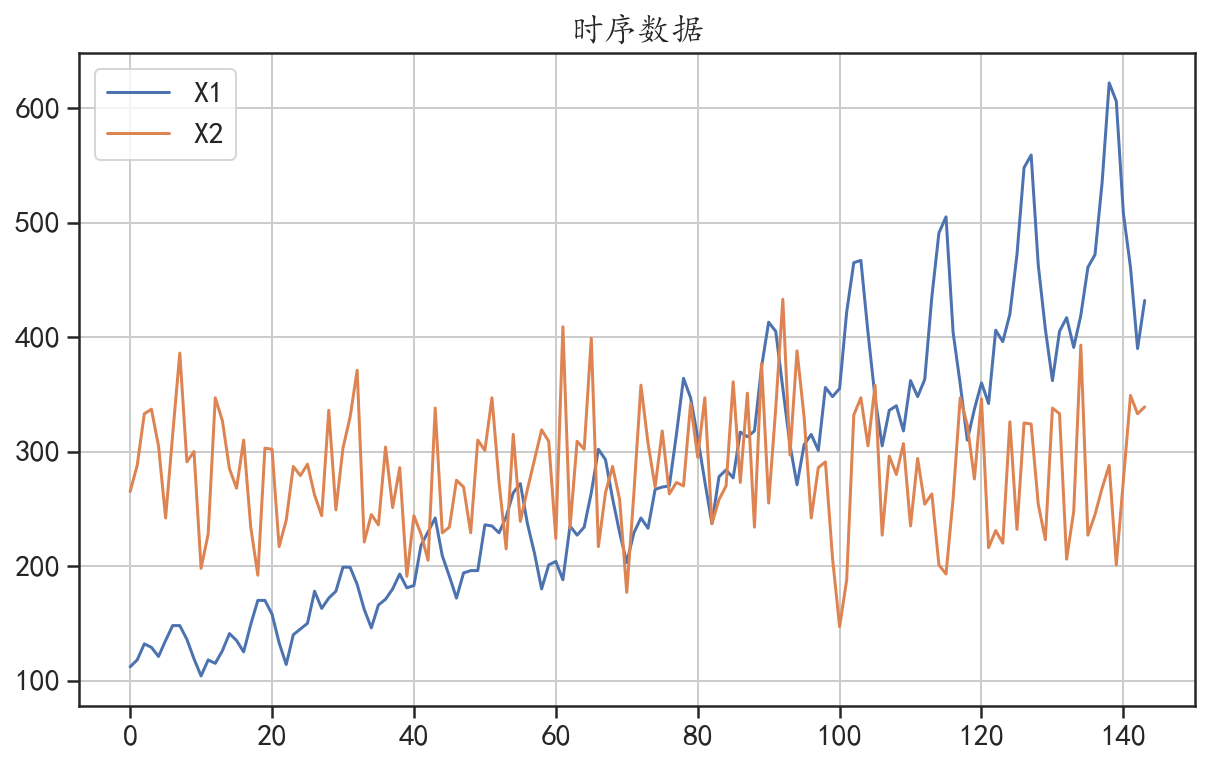

In [3]:
## 读取时间序列数据,该数据包含:X1为飞机乘客数据,X2为一组随机数据
df = pd.read_csv("data/chap6/timeserise.csv")
## 查看数据的变化趋势
df.plot(kind = "line",figsize = (10,6))
plt.grid()
plt.title("时序数据")
plt.show()

In [4]:
## 白噪声检验Ljung-Box检验
## 该检验用来检查序列是否为随机序列，如果是随机序列，那它们的值之间没有任何关系
## 使用LB检验来检验序列是否为白噪声，原假设为在延迟期数内序列之间相互独立。
lags = [4,8,16,32]
LB = sm.stats.diagnostic.acorr_ljungbox(df["X1"],lags = lags,return_df = True)
print("序列X1的检验结果:\n",LB)
LB = sm.stats.diagnostic.acorr_ljungbox(df["X2"],lags = lags,return_df = True)
print("序列X2的检验结果:\n",LB)

## 如果P值小于0.05，说明序列之间不独立，不是白噪声

序列X1的检验结果:
         lb_stat      lb_pvalue
4    427.738684   2.817731e-91
8    709.484498  6.496271e-148
16  1289.037076  1.137910e-264
32  1792.523003   0.000000e+00
序列X2的检验结果:
       lb_stat  lb_pvalue
4    1.822771   0.768314
8    8.452830   0.390531
16  15.508599   0.487750
32  28.717743   0.633459


##### 平稳性检验

In [5]:
## 序列的单位根检验，即检验序列的平稳性
dftest = adfuller(df["X2"],autolag='BIC')
dfoutput = pd.Series(dftest[0:4], index=['adf','p-value','usedlag','Number of Observations Used'])
print("X2单位根检验结果:\n",dfoutput)

dftest = adfuller(df["X1"],autolag='BIC')
dfoutput = pd.Series(dftest[0:4], index=['adf','p-value','usedlag','Number of Observations Used'])
print("X1单位根检验结果:\n",dfoutput)

## 对X1进行一阶差分后的序列进行检验
X1diff = df["X1"].diff().dropna()
dftest = adfuller(X1diff,autolag='BIC')
dfoutput = pd.Series(dftest[0:4], index=['adf','p-value','usedlag','Number of Observations Used'])
print("X1一阶差分单位根检验结果:\n",dfoutput)

## 一阶差分后 P值大于0.05, 小于0.1，可以认为其是平稳的


X2单位根检验结果:
 adf                           -1.124298e+01
p-value                        1.788000e-20
usedlag                        0.000000e+00
Number of Observations Used    1.430000e+02
dtype: float64
X1单位根检验结果:
 adf                              0.815369
p-value                          0.991880
usedlag                         13.000000
Number of Observations Used    130.000000
dtype: float64
X1一阶差分单位根检验结果:
 adf                             -2.829267
p-value                          0.054213
usedlag                         12.000000
Number of Observations Used    130.000000
dtype: float64


In [6]:
## KPSS检验的原假设为：序列x是平稳的。

## 对序列X2使用KPSS检验平稳性
dfkpss = kpss(df["X2"])
dfoutput = pd.Series(dfkpss[0:3], index=["kpss_stat"," p-value"," usedlag"])
print("X2 KPSS检验结果:\n",dfoutput)
## 接受序列平稳的原假设


## 对序列X1使用KPSS检验平稳性
dfkpss = kpss(df["X1"])
dfoutput = pd.Series(dfkpss[0:3], index=["kpss_stat"," p-value"," usedlag"])
print("X1 KPSS检验结果:\n",dfoutput)
## 拒绝序列平稳的原假设

## 对序列X1使用KPSS检验平稳性
dfkpss = kpss(X1diff)
dfoutput = pd.Series(dfkpss[0:3], index=["kpss_stat"," p-value"," usedlag"])
print("X1一阶差分KPSS检验结果:\n",dfoutput)
## 接受序列平稳的原假设

X2 KPSS检验结果:
 kpss_stat     0.087559
 p-value      0.100000
 usedlag     14.000000
dtype: float64
X1 KPSS检验结果:
 kpss_stat     1.052175
 p-value      0.010000
 usedlag     14.000000
dtype: float64
X1一阶差分KPSS检验结果:
 kpss_stat     0.05301
 p-value      0.10000
 usedlag     14.00000
dtype: float64


In [7]:
## 检验ARIMA模型的参数d
X1d = pm.arima.ndiffs(df["X1"], alpha=0.05, test="kpss", max_d=3)
print("使用KPSS方法对序列X1的参数d取值进行预测,d = ",X1d)

X1diffd = pm.arima.ndiffs(X1diff, alpha=0.05, test="kpss", max_d=3)
print("使用KPSS方法对序列X1一阶差分后的参数d取值进行预测,d = ",X1diffd)

X2d = pm.arima.ndiffs(df["X2"], alpha=0.05, test="kpss", max_d=3)
print("使用KPSS方法对序列X2的参数d取值进行预测,d = ",X2d)

使用KPSS方法对序列X1的参数d取值进行预测,d =  1
使用KPSS方法对序列X1一阶差分后的参数d取值进行预测,d =  0
使用KPSS方法对序列X1的参数d取值进行预测,d =  0


In [8]:
## 检验SARIMA模型的参数季节阶数D
X1d = pm.arima.nsdiffs(df["X1"], 12, max_D=2)
print("对序列X1的季节阶数D取值进行预测,D = ",X1d)

X1diffd = pm.arima.nsdiffs(X1diff, 12, max_D=2)
print("序列X1一阶差分后的季节阶数D取值进行预测,D = ",X1diffd)


对序列X1的季节阶数D取值进行预测,D =  1
序列X1一阶差分后的季节阶数D取值进行预测,D =  1


##### 自相关和偏相关分析

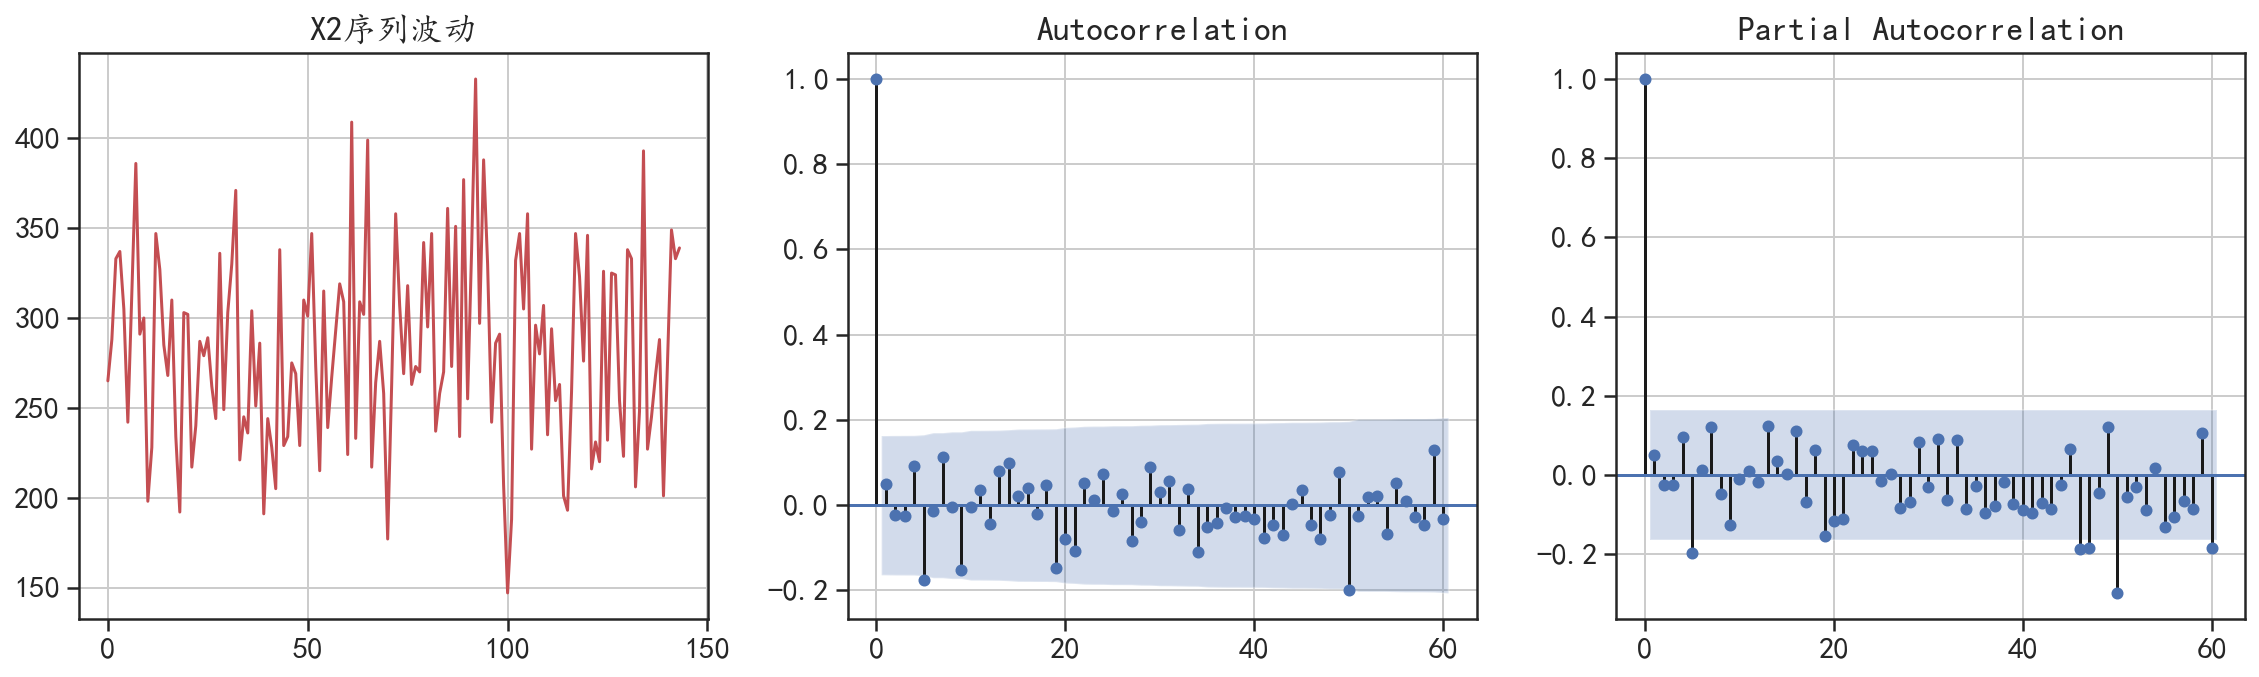

In [9]:
## 对随机序列X2进行自相关和偏相关分析可视化
fig = plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
plt.plot(df["X2"],"r-")
plt.grid()
plt.title("X2序列波动")
ax = fig.add_subplot(1,3,2)
plot_acf(df["X2"], lags=60,ax = ax)
plt.grid()
ax = fig.add_subplot(1,3,3)
plot_pacf(df["X2"], lags=60,ax = ax)
plt.grid()
plt.tight_layout()
plt.show()

在图像中滞后0表示自己和自己的相关性，恒等于1。不用于确定p和q。

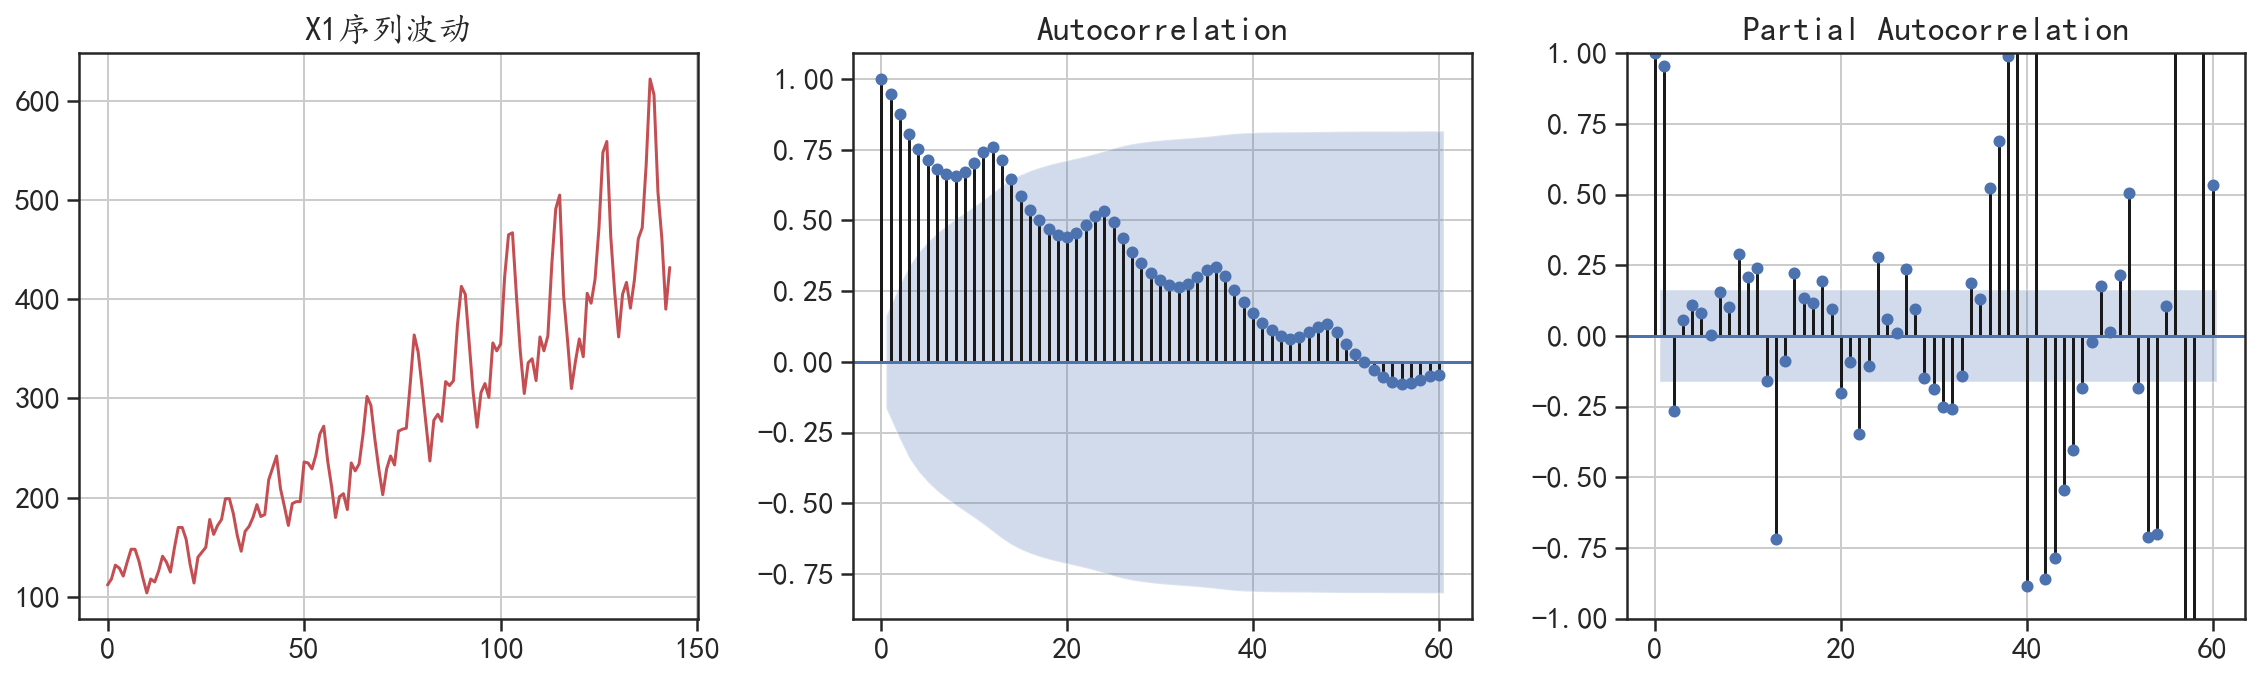

In [10]:
## 对非随机序列X1进行自相关和偏相关分析可视化
fig = plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
plt.plot(df["X1"],"r-")
plt.grid()
plt.title("X1序列波动")
ax = fig.add_subplot(1,3,2)
plot_acf(df["X1"], lags=60,ax = ax)
plt.grid()
ax = fig.add_subplot(1,3,3)
plot_pacf(df["X1"], lags=60,ax = ax)
plt.ylim([-1,1])
plt.grid()
plt.tight_layout()
plt.show()

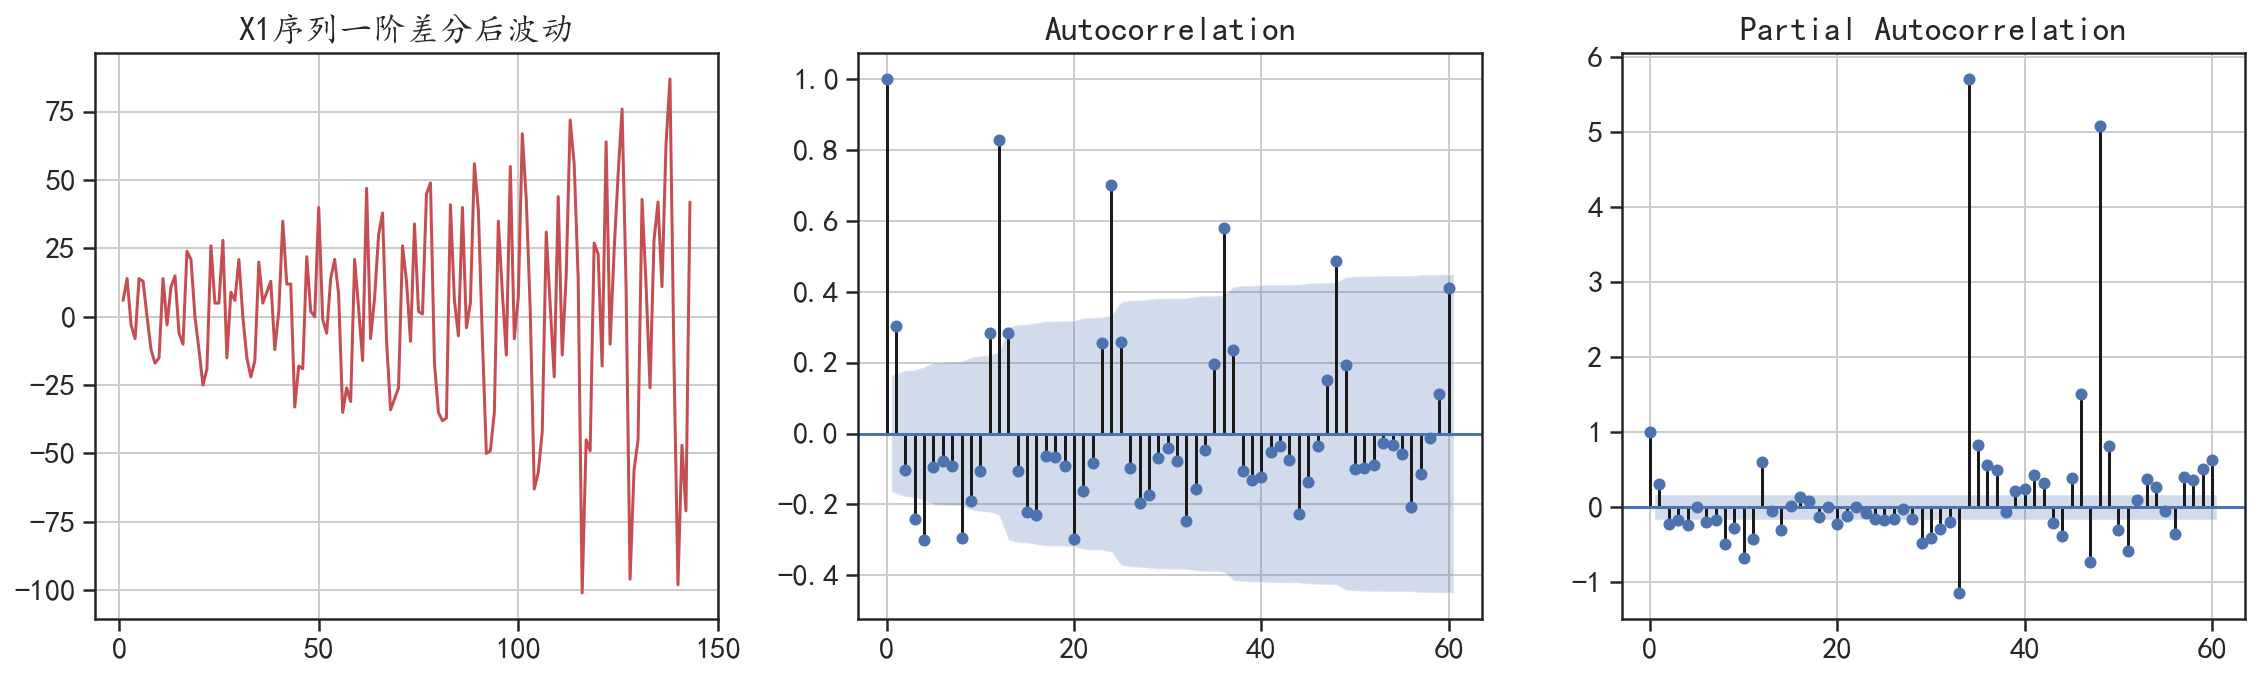

In [11]:
## 对非随机序列X1一阶差分后的序列进行自相关和偏相关分析可视化
fig = plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
plt.plot(X1diff,"r-")
plt.grid()
plt.title("X1序列一阶差分后波动")
ax = fig.add_subplot(1,3,2)
plot_acf(X1diff, lags=60,ax = ax)
plt.grid()
ax = fig.add_subplot(1,3,3)
plot_pacf(X1diff, lags=60,ax = ax)
plt.grid()
plt.tight_layout()
plt.show()

ARMA(p,q)中，自相关系数的滞后，对应着参数q；偏相关系数的滞后对应着参数p。

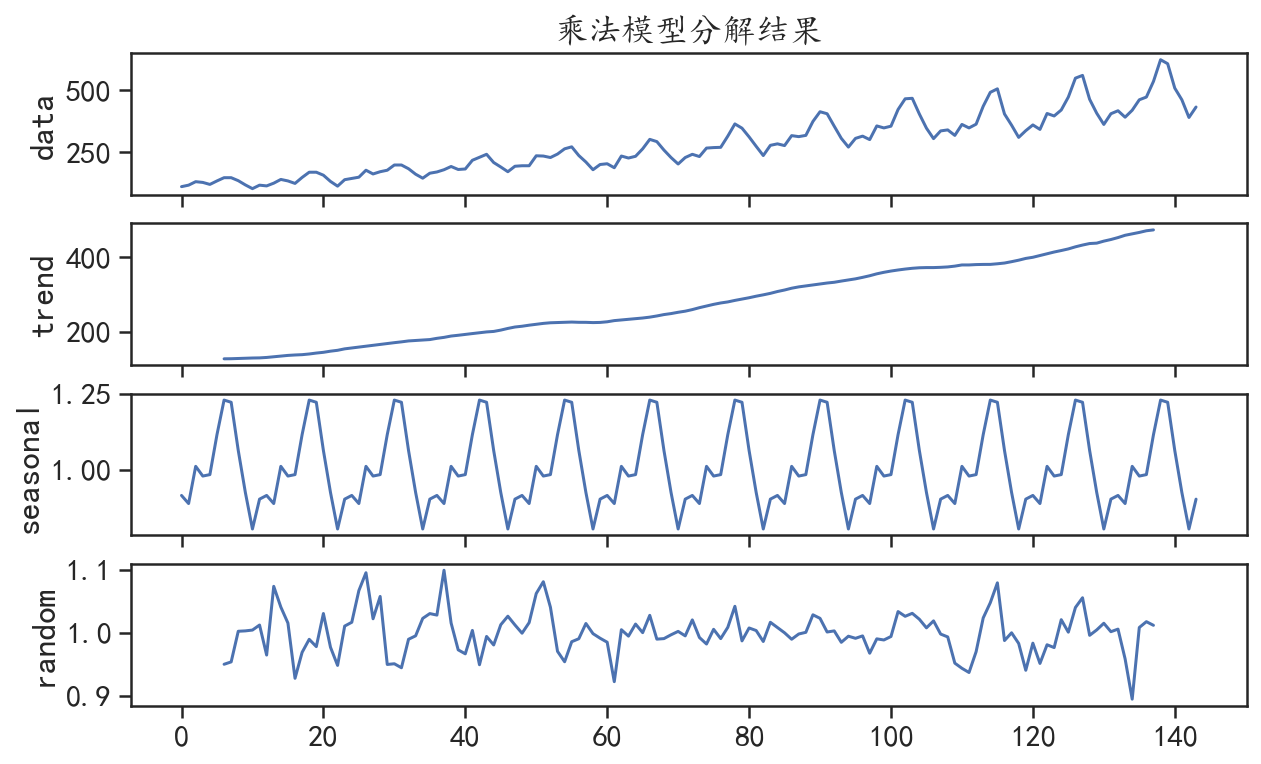

In [12]:
## 时间序列的分解
## 通过观察序列X1，可以发现其既有上升的趋势，也有周期性的趋势，所以可以将该序列进行分解
## 使用乘法模型分解结果(通常适用于有增长趋势的序列)
X1decomp = pm.arima.decompose(df["X1"].values,"multiplicative", m=12)
## 可视化出分解的结果
ax = pm.utils.decomposed_plot(X1decomp,figure_kwargs = {"figsize": (10, 6)},
                              show=False)
ax[0].set_title("乘法模型分解结果")
plt.show()


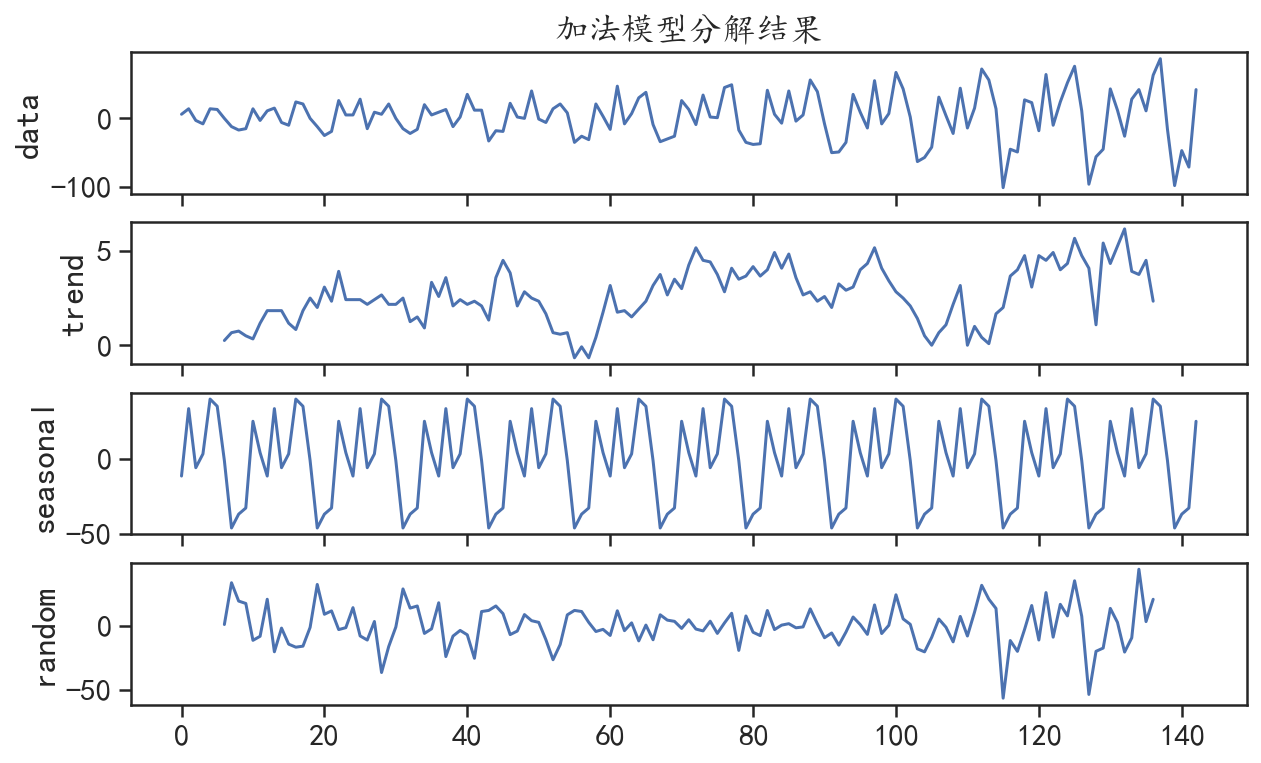

In [13]:
## 使用加法模型分解结果(通常适用于平稳趋势的序列)
X1decomp = pm.arima.decompose(X1diff.values,"additive", m=12)
## 可视化出分解的结果
ax = pm.utils.decomposed_plot(X1decomp,figure_kwargs = {"figsize": (10, 6)},
                              show=False)
ax[0].set_title("加法模型分解结果")
plt.show()

### 6.2 移动平均算法


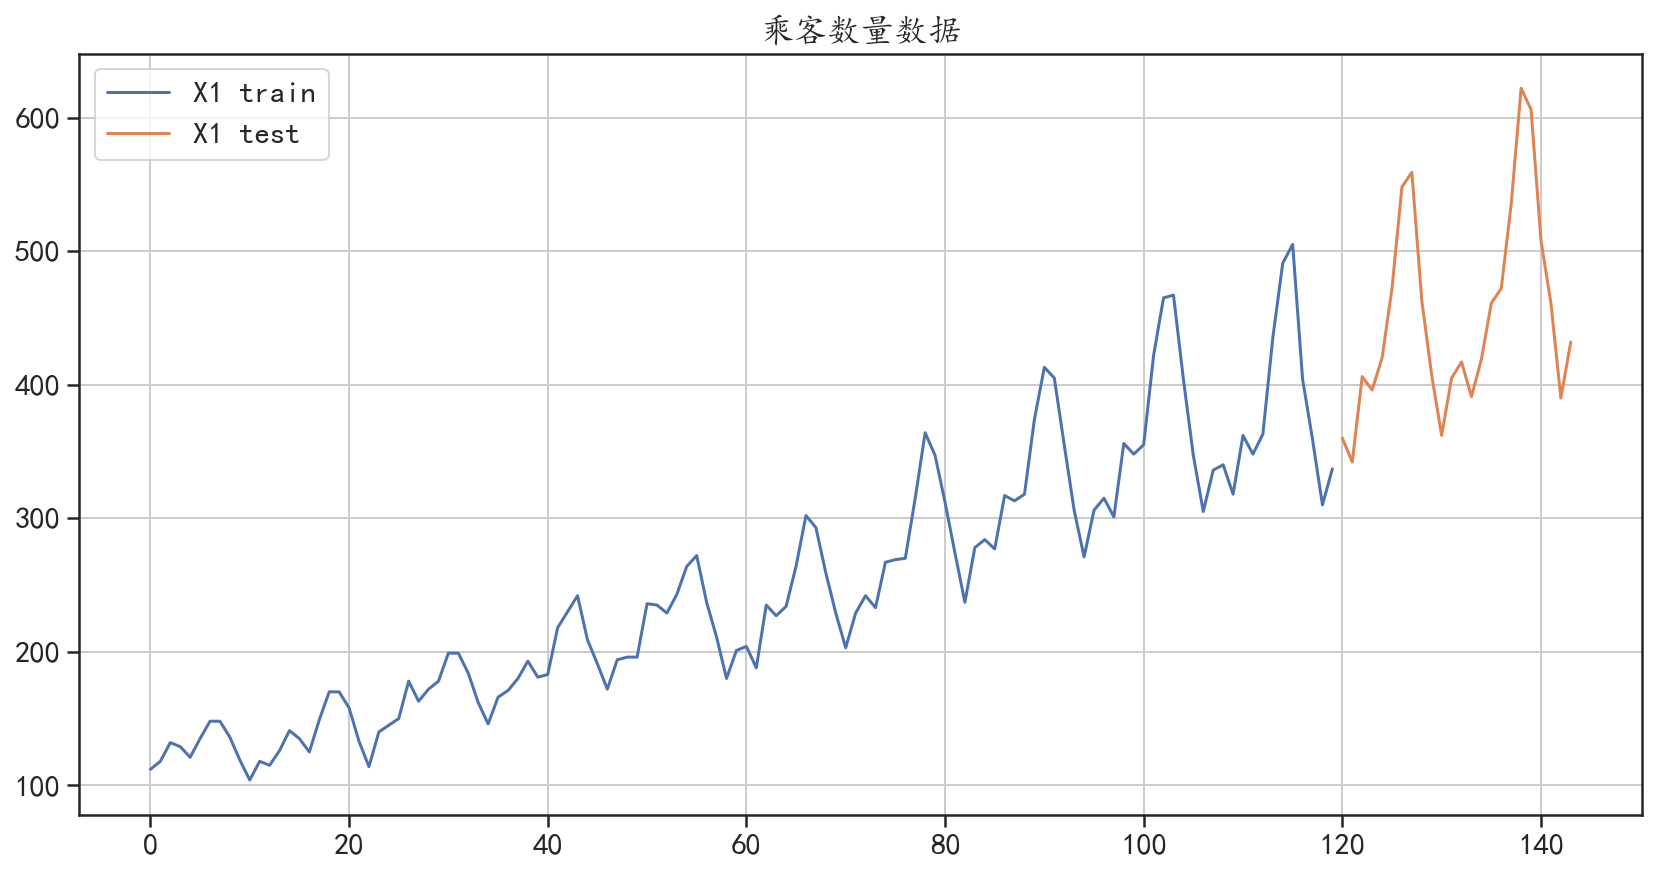

In [14]:
## 数据准备
## 对序列X1进行切分，后面的24个数据用于测试集
train = pd.DataFrame(df["X1"][0:120])
test = pd.DataFrame(df["X1"][120:])
## 可视化切分后的数据
train["X1"].plot(figsize=(14,7), title= "乘客数量数据",label = "X1 train")
test["X1"].plot(label = "X1 test")
plt.legend()
plt.grid()
plt.show()

In [15]:
print(train.shape)
print(test.shape)
df["X1"].shape

(120, 1)
(24, 1)


(144,)

####  6.2.1 简单移动平均


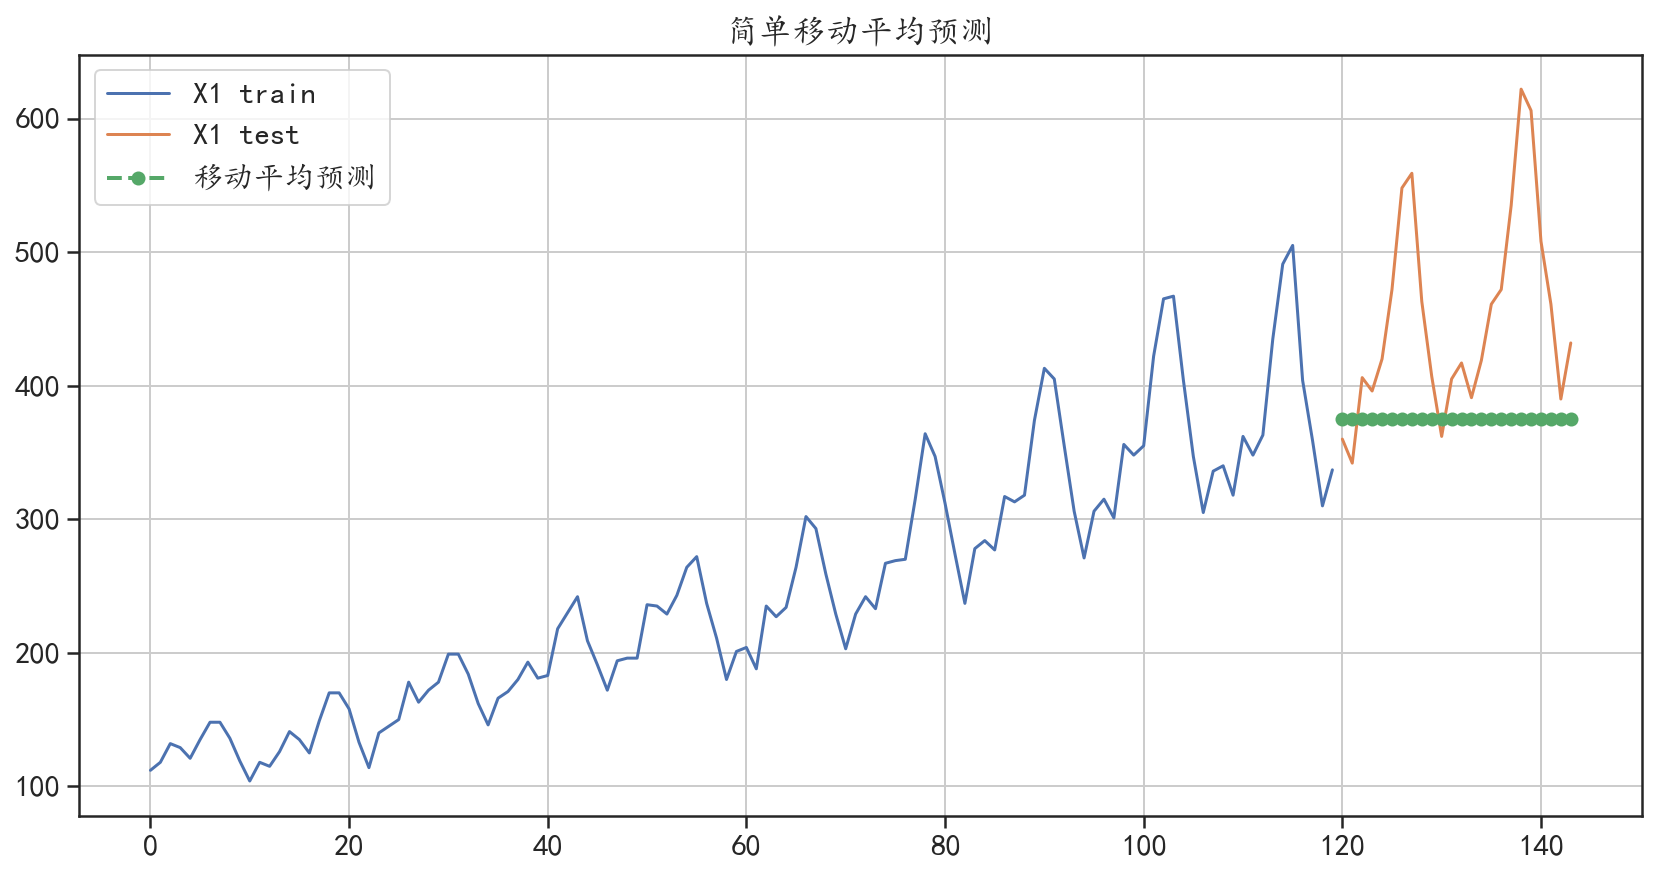

In [16]:
## 简单移动平均进行预测
y_hat_avg = test.copy(deep = False)
y_hat_avg["moving_avg_forecast"] =  train["X1"].rolling(24).mean().iloc[-1]
## 可视化出预测结果
plt.figure(figsize=(14,7))
train["X1"].plot(figsize=(14,7),label = "X1 train")
test["X1"].plot(label = "X1 test")
y_hat_avg["moving_avg_forecast"].plot(style="g--o", lw=2,
                                      label="移动平均预测")
plt.legend()
plt.grid()
plt.title("简单移动平均预测")
plt.show()

In [17]:
## 计算预测结果和真实值的误差
print("预测绝对值误差:",mean_absolute_error(test["X1"],y_hat_avg["moving_avg_forecast"]))

预测绝对值误差: 82.55208333333336


####    6.2.2 简单指数平滑法


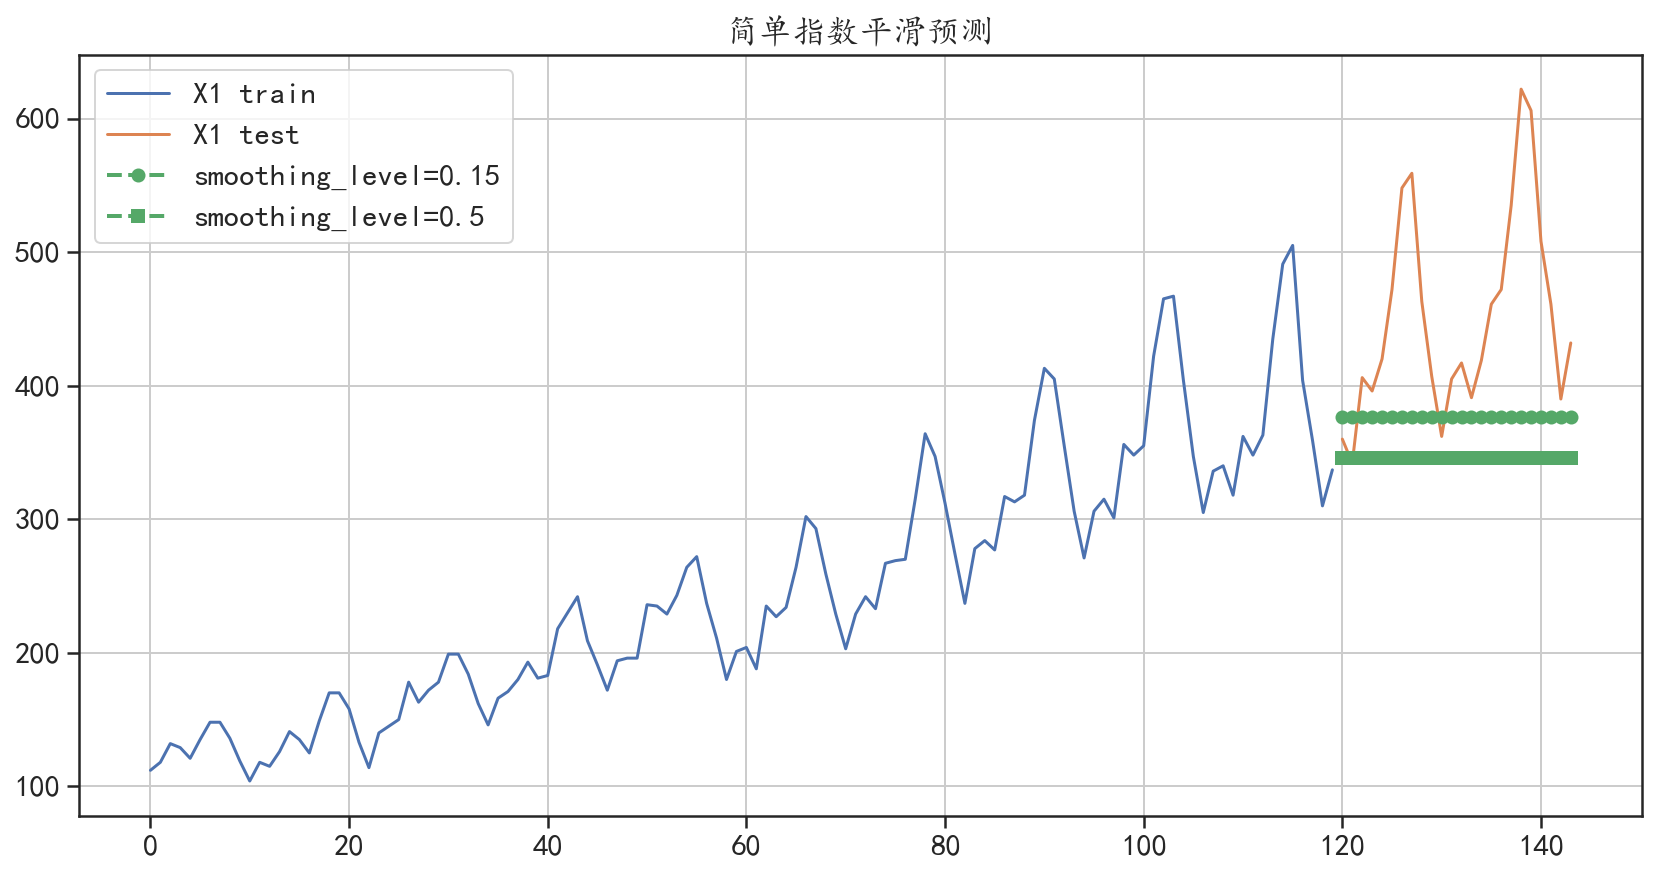

smoothing_level=0.15,预测绝对值误差: 81.10115706423566
smoothing_level=0.5,预测绝对值误差: 106.813228720506


In [18]:
## 数据准备
y_hat_avg = test.copy(deep = False)
## 模型构建
model1 = SimpleExpSmoothing(train["X1"].values).fit(smoothing_level=0.15)
y_hat_avg["exp_smooth_forecast1"] = model1.forecast(len(test))

model2 = SimpleExpSmoothing(train["X1"].values).fit(smoothing_level=0.5)
y_hat_avg["exp_smooth_forecast2"] = model2.forecast(len(test))

## 可视化出预测结果
plt.figure(figsize=(14,7))
train["X1"].plot(figsize=(14,7),label = "X1 train")
test["X1"].plot(label = "X1 test")
y_hat_avg["exp_smooth_forecast1"].plot(style="g--o", lw=2,
                                      label="smoothing_level=0.15")
y_hat_avg["exp_smooth_forecast2"].plot(style="g--s", lw=2,
                                      label="smoothing_level=0.5")
plt.legend()
plt.grid()
plt.title("简单指数平滑预测")
plt.show()

## 计算预测结果和真实值的误差
print("smoothing_level=0.15,预测绝对值误差:",
      mean_absolute_error(test["X1"],y_hat_avg["exp_smooth_forecast1"]))
print("smoothing_level=0.5,预测绝对值误差:",
      mean_absolute_error(test["X1"],y_hat_avg["exp_smooth_forecast2"]))

#### 6.2.3 霍尔特(Holt)线性趋势法

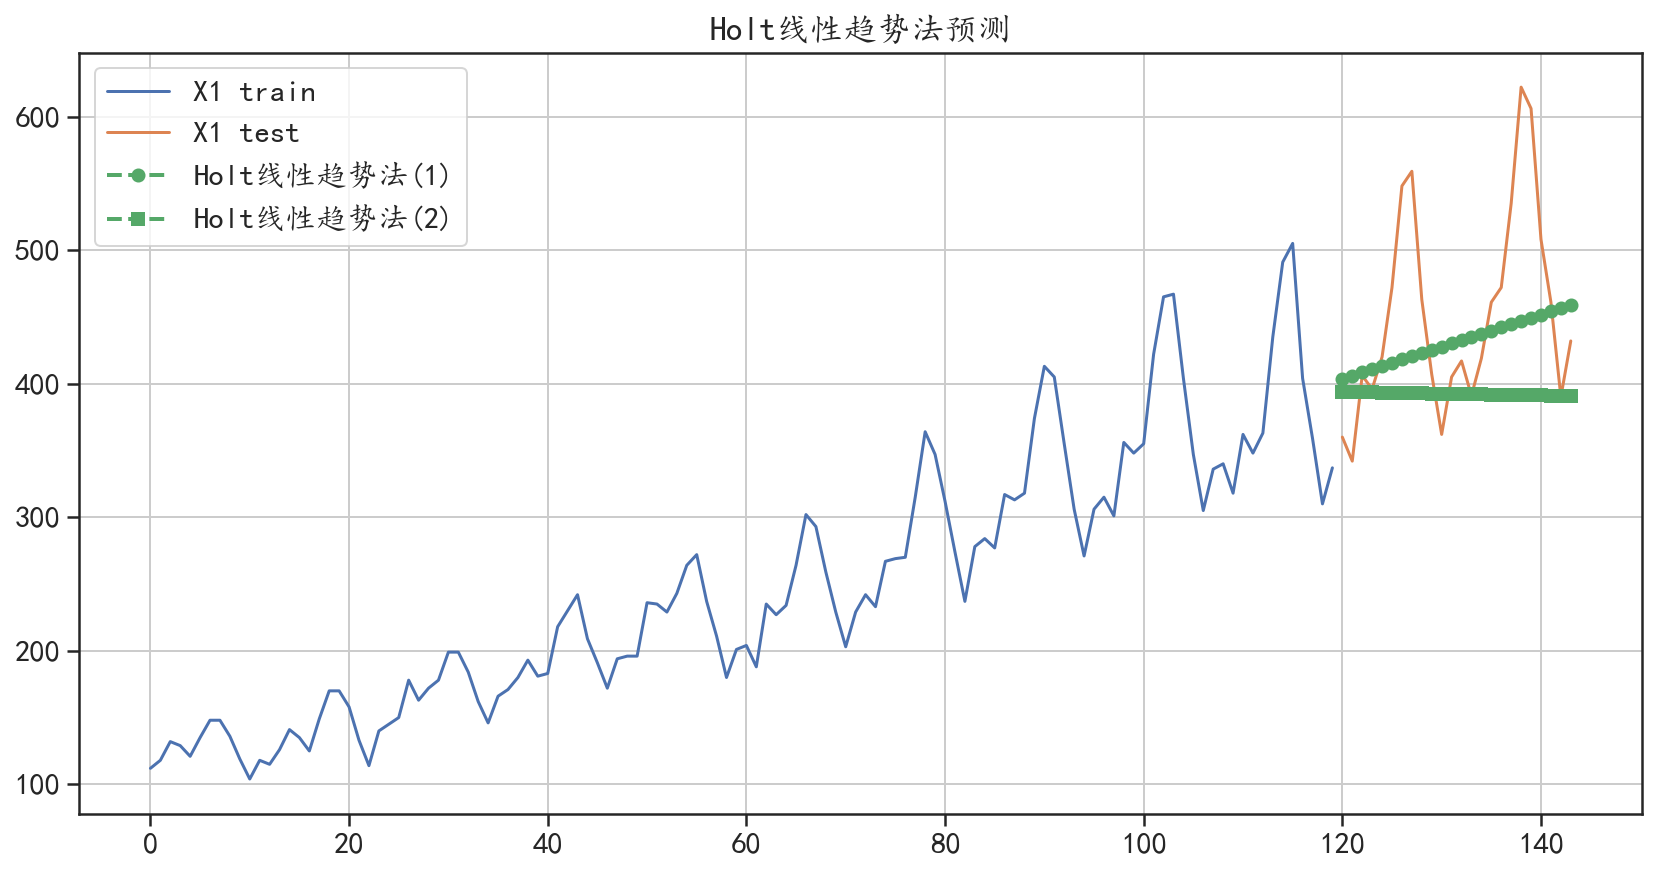

smoothing_slope = 0.05,预测绝对值误差: 54.727467142360275
smoothing_slope = 0.25,预测绝对值误差: 69.79052992788556


In [19]:
## 数据准备
y_hat_avg = test.copy(deep = False)
## 模型构建
model1 = Holt(train["X1"].values).fit(smoothing_level=0.1,
                                      smoothing_slope = 0.05)
y_hat_avg["holt_forecast1"] = model1.forecast(len(test))

model2 = Holt(train["X1"].values).fit(smoothing_level=0.1,
                                      smoothing_slope = 0.25)
y_hat_avg["holt_forecast2"] = model2.forecast(len(test))


## 可视化出预测结果
plt.figure(figsize=(14,7))
train["X1"].plot(figsize=(14,7),label = "X1 train")
test["X1"].plot(label = "X1 test")
y_hat_avg["holt_forecast1"].plot(style="g--o", lw=2,
                                 label="Holt线性趋势法(1)")
y_hat_avg["holt_forecast2"].plot(style="g--s", lw=2,
                                 label="Holt线性趋势法(2)")
plt.legend()
plt.grid()
plt.title("Holt线性趋势法预测")
plt.show()

## 计算预测结果和真实值的误差
print("smoothing_slope = 0.05,预测绝对值误差:",
      mean_absolute_error(test["X1"],y_hat_avg["holt_forecast1"]))
print("smoothing_slope = 0.25,预测绝对值误差:",
      mean_absolute_error(test["X1"],y_hat_avg["holt_forecast2"]))

#### 6.2.4 Holt-Winters季节性预测模型


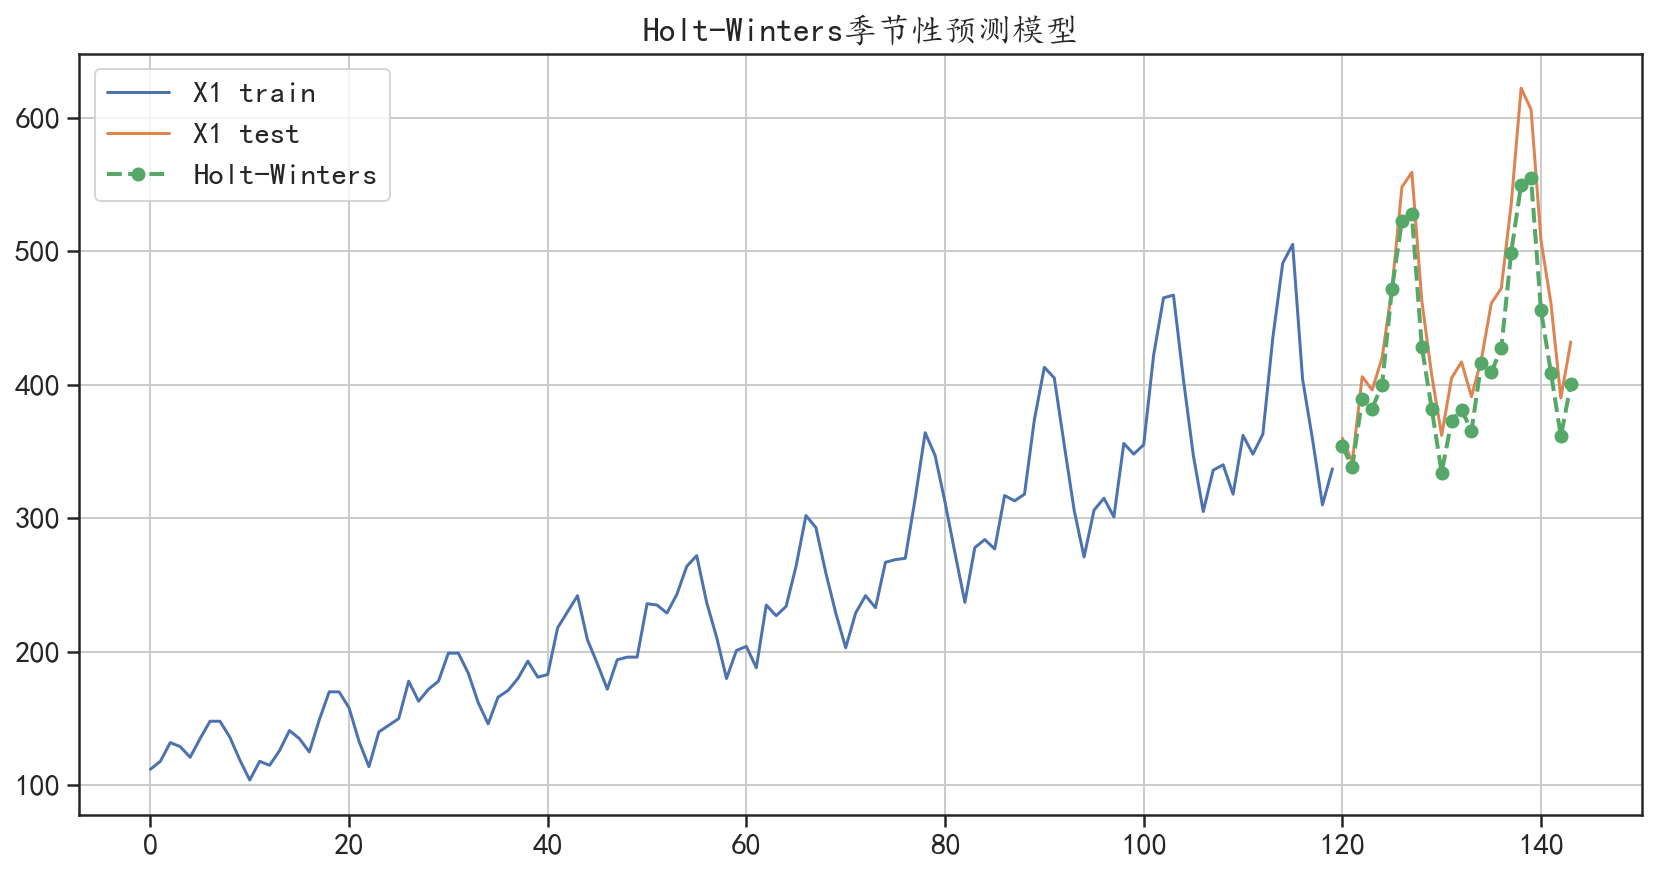

Holt-Winters季节性预测模型,预测绝对值误差: 30.06821059070873


In [20]:
## 数据准备
y_hat_avg = test.copy(deep = False)
## 模型构建
model1 = ExponentialSmoothing(train["X1"].values,
                              seasonal_periods=12, # 周期性为12  
                              trend="add", seasonal="add").fit()
y_hat_avg["holt_winter_forecast1"] = model1.forecast(len(test))

## 可视化出预测结果
plt.figure(figsize=(14,7))
train["X1"].plot(figsize=(14,7),label = "X1 train")
test["X1"].plot(label = "X1 test")
y_hat_avg["holt_winter_forecast1"].plot(style="g--o", lw=2,
                                 label="Holt-Winters")

plt.legend()
plt.grid()
plt.title("Holt-Winters季节性预测模型")
plt.show()

## 计算预测结果和真实值的误差
print("Holt-Winters季节性预测模型,预测绝对值误差:",
      mean_absolute_error(test["X1"],y_hat_avg["holt_winter_forecast1"]))


### 6.3 ARIMA模型
 

In [21]:
## 注意针对乘客数据X1，使用AR模型或者ARMA模型进行预测，并不是非常的合适，
## 这里是使用AR和ARMA模型进行预测的目的主要是为了和更好的模型预测结果进行对比

####   AR模型
   

In [22]:
## 使用AR模型对乘客数据进行预测 

## 经过前面序列的偏相关系数的可视化结果，使用AR(2)模型可对序列进行建模
## 数据准备
y_hat = test.copy(deep = False)
## 模型构建
ar_model = ARMA(train["X1"].values,order = (2,0)).fit()
## 输出拟合模型的结果
print(ar_model.summary())

## AIC=1141.989；BIC= 1153.138；两个系数是显著的

                              ARMA Model Results                              
Dep. Variable:                      y   No. Observations:                  120
Model:                     ARMA(2, 0)   Log Likelihood                -566.994
Method:                       css-mle   S.D. of innovations             26.976
Date:                Thu, 23 Jul 2020   AIC                           1141.989
Time:                        16:05:02   BIC                           1153.138
Sample:                             0   HQIC                          1146.517
                                                                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        243.4434     39.119      6.223      0.000     166.771     320.116
ar.L1.y        1.2573      0.086     14.568      0.000       1.088       1.426
ar.L2.y       -0.3152      0.087     -3.623      0.0

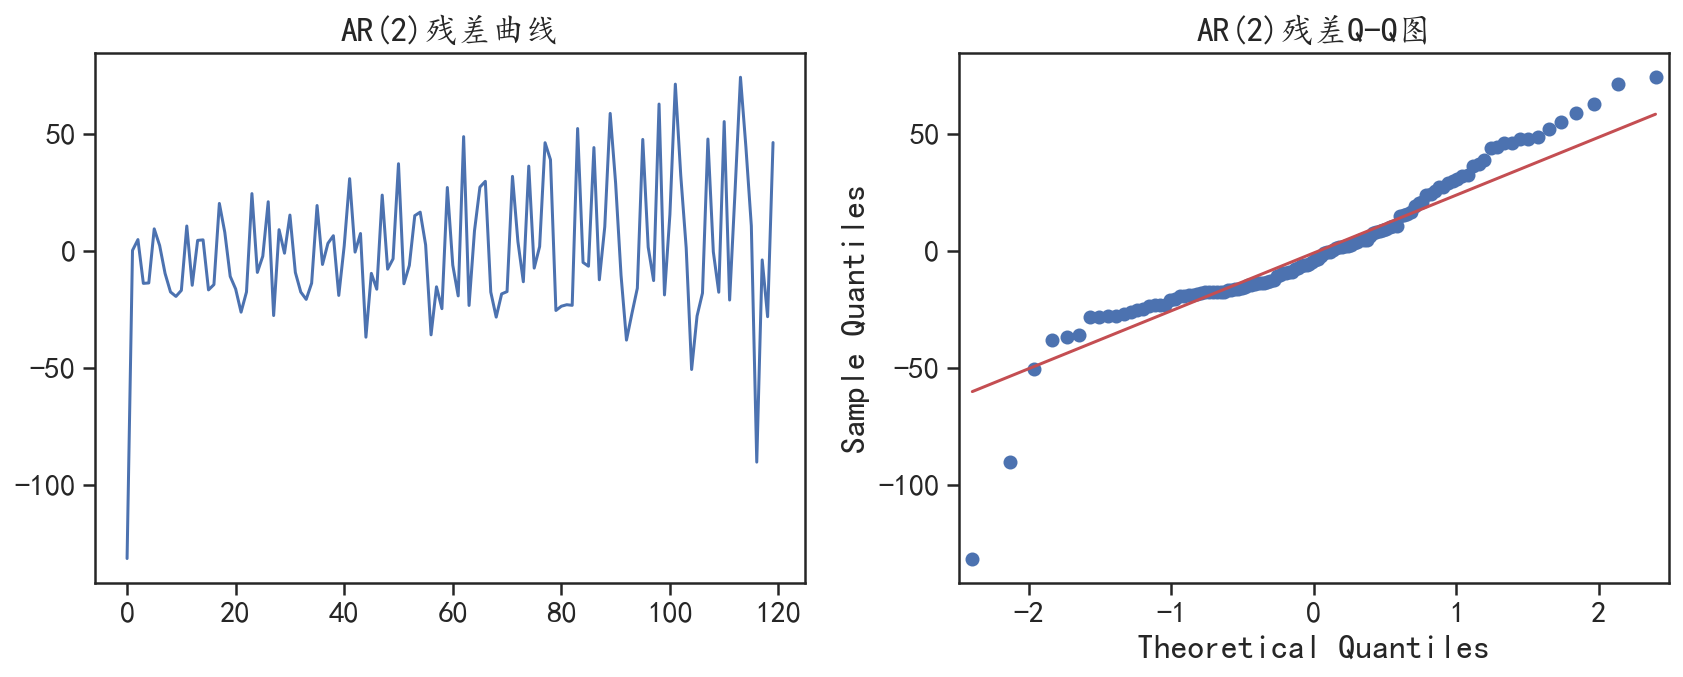

In [23]:
## 查看模型的拟合残差分布
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(1,2,1)
plt.plot(ar_model.resid)
plt.title("AR(2)残差曲线")
## 检查残差是否符合正太分布
ax = fig.add_subplot(1,2,2)
sm.qqplot(ar_model.resid, line='q', ax=ax)
plt.title("AR(2)残差Q-Q图")
plt.tight_layout()
plt.show()

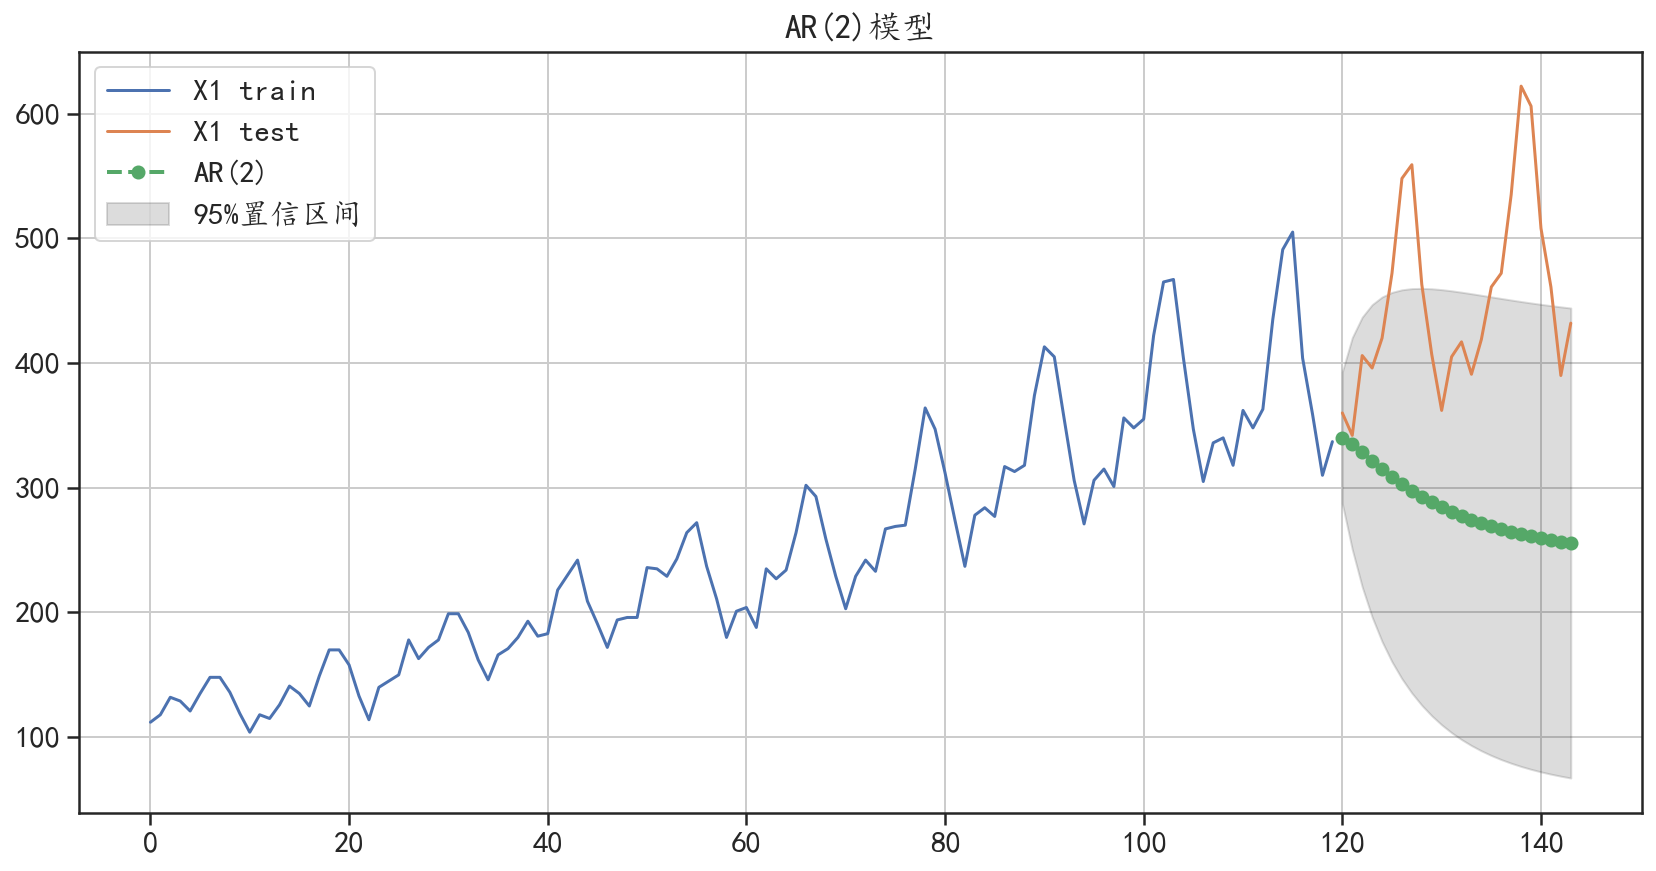

AR(2)模型预测的绝对值误差: 165.79608244918572


In [24]:
## 预测未来24个数据，并输出95%置信区间
pre, se, conf = ar_model.forecast(24, alpha=0.05)  
## 整理数据
y_hat["ar2_pre"] = pre
y_hat["ar2_pre_lower"] = conf[:,0]
y_hat["ar2_pre_upper"] = conf[:,1]
## 可视化出预测结果
plt.figure(figsize=(14,7))
train["X1"].plot(figsize=(14,7),label = "X1 train")
test["X1"].plot(label = "X1 test")
y_hat["ar2_pre"].plot(style="g--o", lw=2,label="AR(2)")
## 可视化出置信区间
plt.fill_between(y_hat.index, y_hat["ar2_pre_lower"], 
                 y_hat["ar2_pre_upper"],color='k',alpha=.15,
                 label = "95%置信区间")
plt.legend()
plt.grid()
plt.title("AR(2)模型")
plt.show()

# 计算预测结果和真实值的误差
print("AR(2)模型预测的绝对值误差:",
      mean_absolute_error(test["X1"],y_hat["ar2_pre"]))


可以发现使用AR(2)的预测效果并不好

#### ARMA模型


In [25]:
## 尝试使用ARMA模型进行预测

## 根据前面的自相关系数和偏相关系数,为了降低模型的复杂读,可以使用ARMA(2,1)

## 数据准备
y_hat = test.copy(deep = False)
## 模型构建
arma_model = ARMA(train["X1"].values,order = (2,1)).fit()
## 输出拟合模型的结果
print(arma_model.summary())

## AIC=1141.989；BIC= 1153.138；两个系数是显著的


                              ARMA Model Results                              
Dep. Variable:                      y   No. Observations:                  120
Model:                     ARMA(2, 1)   Log Likelihood                -564.185
Method:                       css-mle   S.D. of innovations             26.294
Date:                Thu, 23 Jul 2020   AIC                           1138.371
Time:                        16:05:03   BIC                           1152.308
Sample:                             0   HQIC                          1144.031
                                                                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        243.7449     46.844      5.203      0.000     151.933     335.557
ar.L1.y        0.4617      0.156      2.966      0.003       0.157       0.767
ar.L2.y        0.4539      0.155      2.933      0.0

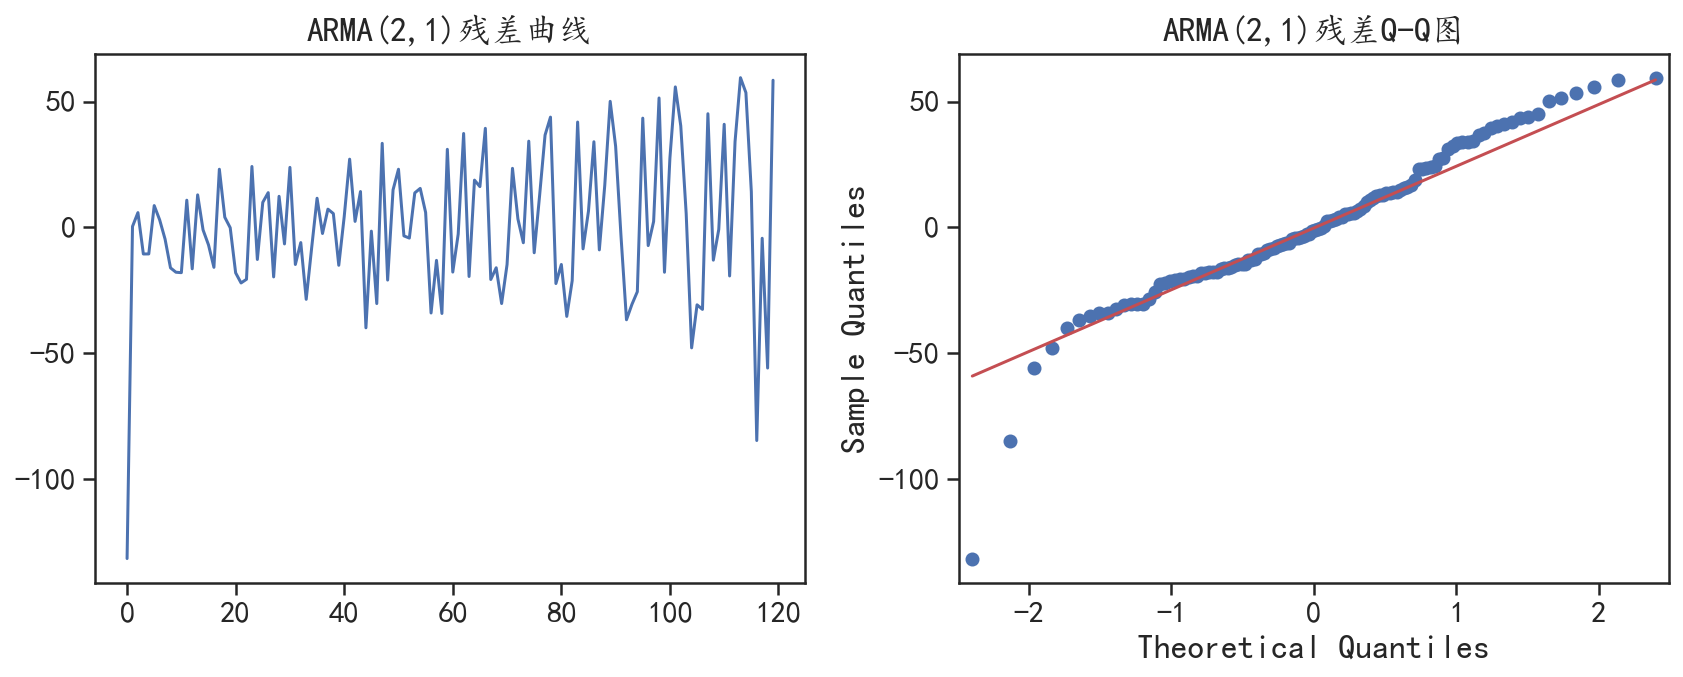

In [26]:
## 查看模型的拟合残差分布
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(1,2,1)
plt.plot(arma_model.resid)
plt.title("ARMA(2,1)残差曲线")
## 检查残差是否符合正太分布
ax = fig.add_subplot(1,2,2)
sm.qqplot(arma_model.resid, line='q', ax=ax)
plt.title("ARMA(2,1)残差Q-Q图")
plt.tight_layout()
plt.show()

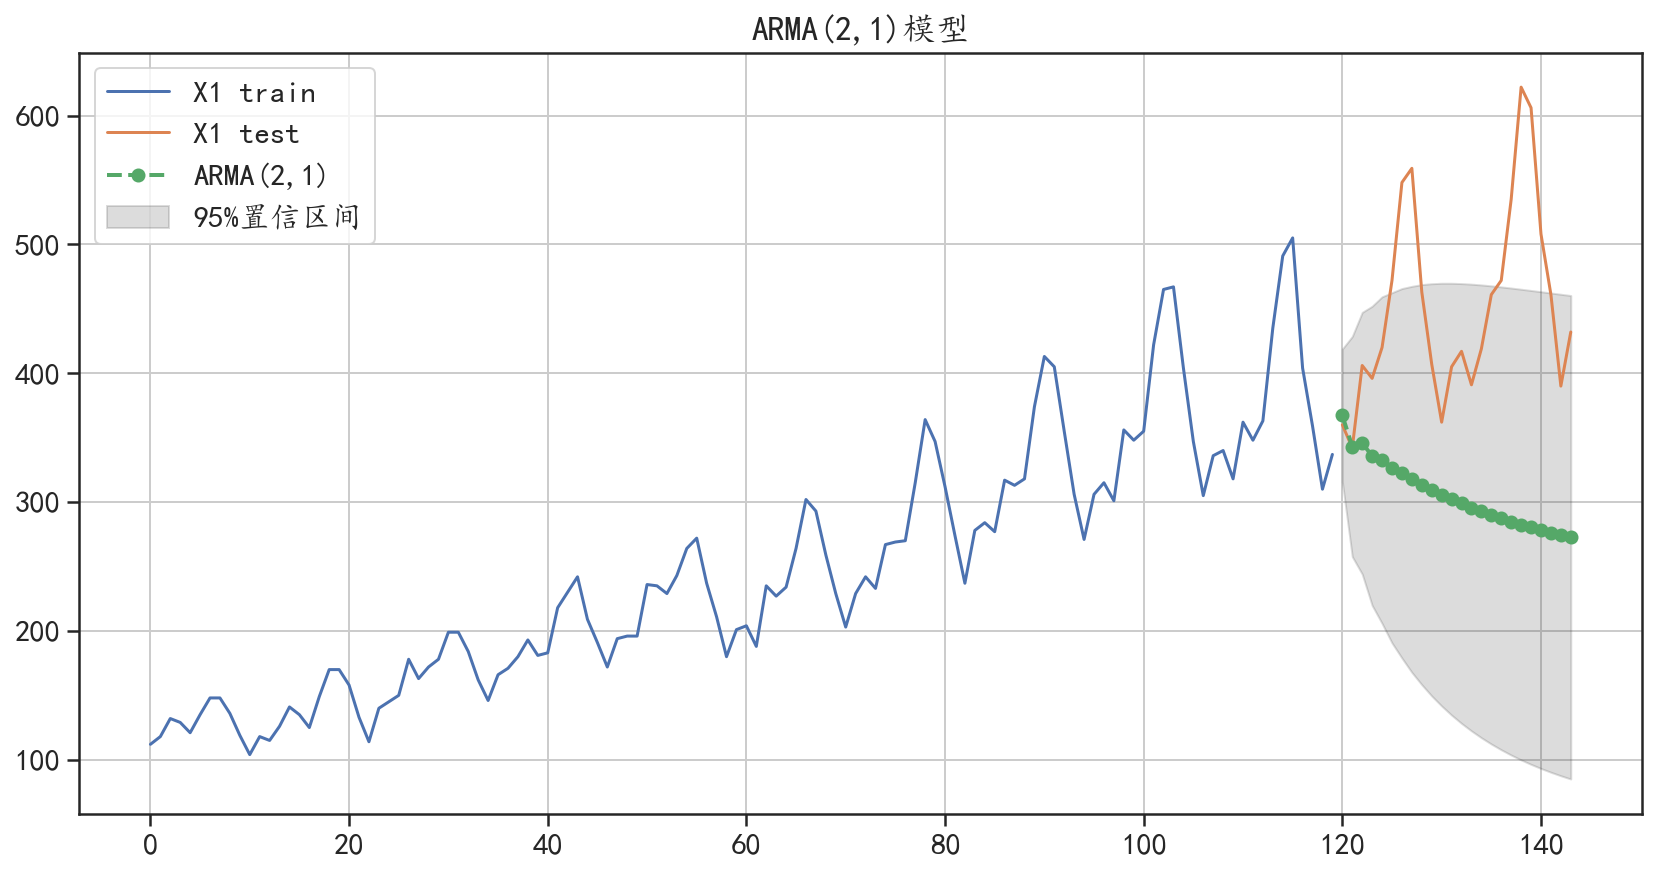

ARMA模型预测的绝对值误差: 147.26531763335154


In [27]:
## 预测未来24个数据，并输出95%置信区间
pre, se, conf = arma_model.forecast(24, alpha=0.05)  
## 整理数据
y_hat["arma_pre"] = pre
y_hat["arma_pre_lower"] = conf[:,0]
y_hat["arma_pre_upper"] = conf[:,1]
## 可视化出预测结果
plt.figure(figsize=(14,7))
train["X1"].plot(figsize=(14,7),label = "X1 train")
test["X1"].plot(label = "X1 test")
y_hat["arma_pre"].plot(style="g--o", lw=2,label="ARMA(2,1)")
## 可视化出置信区间
plt.fill_between(y_hat.index, y_hat["arma_pre_lower"], 
                 y_hat["arma_pre_upper"],color='k',alpha=.15,
                 label = "95%置信区间")
plt.legend()
plt.grid()
plt.title("ARMA(2,1)模型")
plt.show()

# 计算预测结果和真实值的误差
print("ARMA模型预测的绝对值误差:",
      mean_absolute_error(test["X1"],y_hat["arma_pre"]))


##### 针对ARMA模型自动选择合适的参数


In [28]:
## 自动搜索合适的参数
model = pm.auto_arima(train["X1"].values,
                      start_p=1, start_q=1, # p,q的开始值
                      max_p=12, max_q=12, # 最大的p和q
                      d = 0,            # 寻找ARMA模型参数
                      m=1,              # 序列的周期
                      seasonal=False,   # 没有季节性趋势
                      trace=True,error_action='ignore',  
                      suppress_warnings=True, stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
Fit ARIMA(1,0,1)x(0,0,0,0) [intercept=True]; AIC=1138.852, BIC=1150.002, Time=0.083 seconds
Fit ARIMA(0,0,0)x(0,0,0,0) [intercept=True]; AIC=1436.325, BIC=1441.900, Time=0.008 seconds
Fit ARIMA(1,0,0)x(0,0,0,0) [intercept=True]; AIC=1152.396, BIC=1160.759, Time=0.039 seconds
Fit ARIMA(0,0,1)x(0,0,0,0) [intercept=True]; AIC=1295.994, BIC=1304.357, Time=0.043 seconds
Near non-invertible roots for order (0, 0, 1)(0, 0, 0, 0); setting score to inf (at least one inverse root too close to the border of the unit circle: 0.999)
Fit ARIMA(0,0,0)x(0,0,0,0) [intercept=False]; AIC=1680.279, BIC=1683.067, Time=0.006 seconds
Fit ARIMA(2,0,1)x(0,0,0,0) [intercept=True]; AIC=1138.371, BIC=1152.308, Time=0.141 seconds
Fit ARIMA(2,0,0)x(0,0,0,0) [intercept=True]; AIC=1141.989, BIC=1153.138, Time=0.070 seconds
Fit ARIMA(3,0,1)x(0,0,0,0) [intercept=True]; AIC=1138.731, BIC=1155.456, Time=0.191 seconds
Fit ARIMA(2,0,2)x(0,0,0,0) [intercept=True]; AIC=1138.677, BIC

可以发现找到的较好模型为ARIMA(3,0,2)x(0,0,0,0),即ARMA(3,2)模型

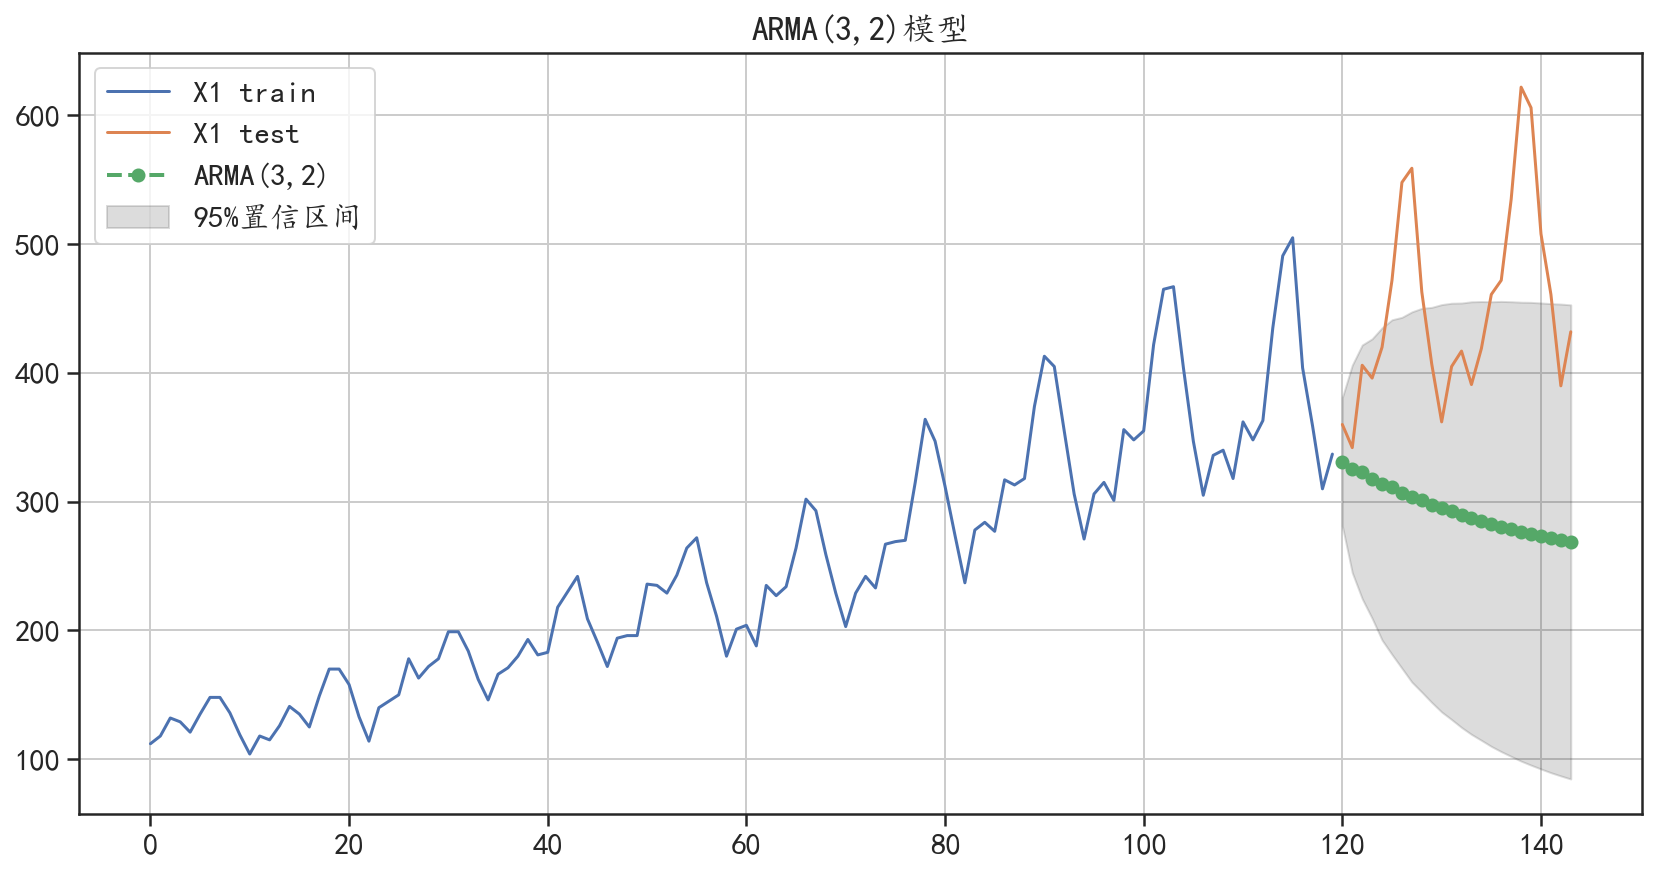

ARMA模型预测的绝对值误差: 158.11464180972925


In [29]:
## 使用ARMA(3,2)对测试集进行预测
pre, conf = model.predict(n_periods=24, alpha=0.05,
                          return_conf_int=True)
## 可视化ARMA(3,2)的预测结果，整理数据
y_hat["arma_pre"] = pre
y_hat["arma_pre_lower"] = conf[:,0]
y_hat["arma_pre_upper"] = conf[:,1]
## 可视化出预测结果
plt.figure(figsize=(14,7))
train["X1"].plot(figsize=(14,7),label = "X1 train")
test["X1"].plot(label = "X1 test")
y_hat["arma_pre"].plot(style="g--o", lw=2,label="ARMA(3,2)")
## 可视化出置信区间
plt.fill_between(y_hat.index, y_hat["arma_pre_lower"], 
                 y_hat["arma_pre_upper"],color='k',alpha=.15,
                 label = "95%置信区间")
plt.legend()
plt.grid()
plt.title("ARMA(3,2)模型")
plt.show()

# 计算预测结果和真实值的误差
print("ARMA模型预测的绝对值误差:",
      mean_absolute_error(test["X1"],y_hat["arma_pre"]))

In [30]:
## 可以发现使用自动ARMA(3,2)模型的效果并没有ARMA(2,1)的预测效果好

####    ARIMA模型


In [31]:
## 建立ARIMA(2,1,1)模型
## 数据准备
y_hat = test.copy(deep = False)
## 模型构建
arima_model = ARIMA(train["X1"].values,order = (2,1,1)).fit()
## 输出拟合模型的结果
print(arima_model.summary())

## AIC=1099.005；BIC= 1112.900；两个系数是显著的


                             ARIMA Model Results                              
Dep. Variable:                    D.y   No. Observations:                  119
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -544.502
Method:                       css-mle   S.D. of innovations             23.067
Date:                Thu, 23 Jul 2020   AIC                           1099.005
Time:                        16:05:06   BIC                           1112.900
Sample:                             1   HQIC                          1104.647
                                                                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5039      0.144     17.339      0.000       2.221       2.787
ar.L1.D.y      1.0825      0.079     13.758      0.000       0.928       1.237
ar.L2.D.y     -0.5024      0.080     -6.281      0.0

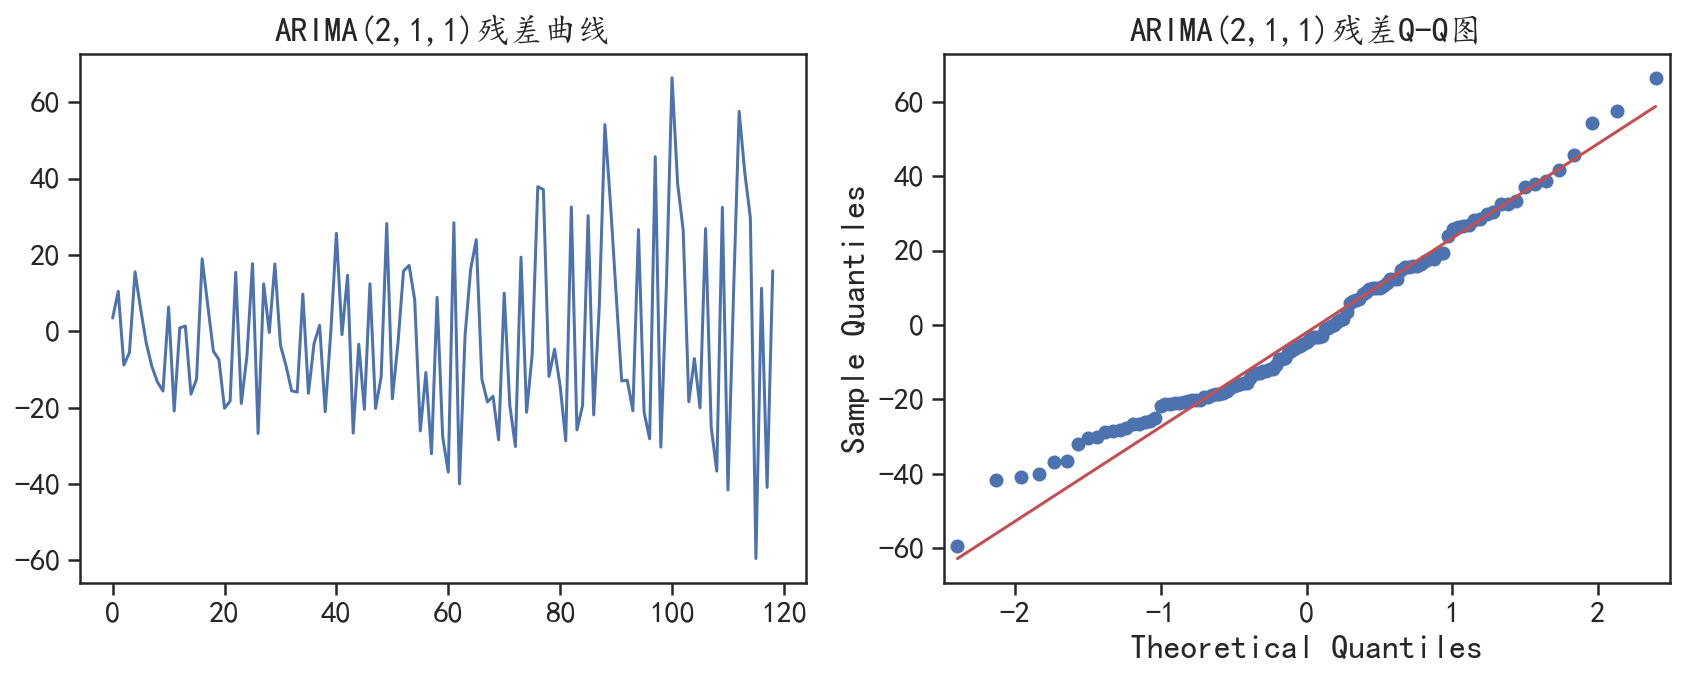

In [32]:
## 查看模型的拟合残差分布
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(1,2,1)
plt.plot(arima_model.resid)
plt.title("ARIMA(2,1,1)残差曲线")
## 检查残差是否符合正太分布
ax = fig.add_subplot(1,2,2)
sm.qqplot(arima_model.resid, line='q', ax=ax)
plt.title("ARIMA(2,1,1)残差Q-Q图")
plt.tight_layout()
plt.show()

## 可以发现此时的残差更符合正态分布

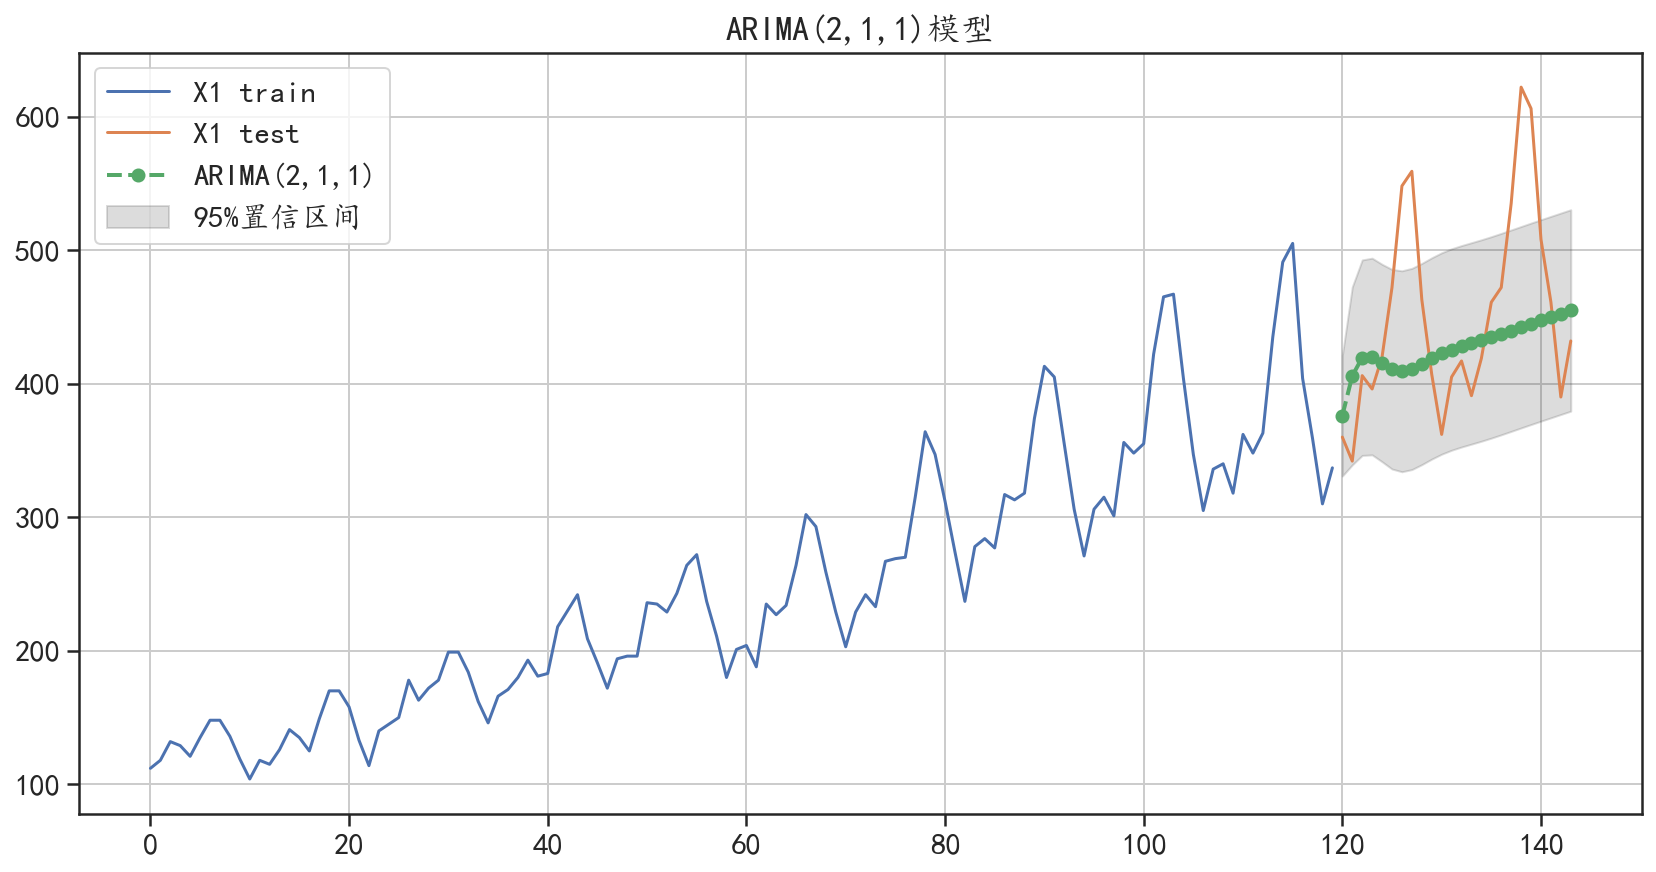

ARIMA模型预测的绝对值误差: 55.38767065734245


In [33]:
## 可视化模型对测试集的预测结果
## 预测未来24个数据，并输出95%置信区间
pre, se, conf = arima_model.forecast(24, alpha=0.05)  
## 整理数据
y_hat["arima_pre"] = pre
y_hat["arima_pre_lower"] = conf[:,0]
y_hat["arima_pre_upper"] = conf[:,1]
## 可视化出预测结果
plt.figure(figsize=(14,7))
train["X1"].plot(figsize=(14,7),label = "X1 train")
test["X1"].plot(label = "X1 test")
y_hat["arima_pre"].plot(style="g--o", lw=2,label="ARIMA(2,1,1)")
## 可视化出置信区间
plt.fill_between(y_hat.index, y_hat["arima_pre_lower"], 
                 y_hat["arima_pre_upper"],color='k',alpha=.15,
                 label = "95%置信区间")
plt.legend()
plt.grid()
plt.title("ARIMA(2,1,1)模型")
plt.show()

# 计算预测结果和真实值的误差
print("ARIMA模型预测的绝对值误差:",
      mean_absolute_error(test["X1"],y_hat["arima_pre"]))

## 可以发现ARIMA(2,1,1)很好的拟合了数据的增长趋势


In [34]:
## 自动搜索合适的参数的ARIMA模型
model = pm.auto_arima(train["X1"].values,
                      start_p=1, start_q=1, # p,q的开始值
                      max_p=12, max_q=12, # 最大的p和q
                      test="kpss",       # 使用kpss检验确定d
                      m=1,              # 序列的周期
                      seasonal=False,   # 没有季节性趋势
                      trace=True,error_action='ignore',  
                      suppress_warnings=True, stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
Fit ARIMA(1,1,1)x(0,0,0,0) [intercept=True]; AIC=1126.948, BIC=1138.064, Time=0.095 seconds
Fit ARIMA(0,1,0)x(0,0,0,0) [intercept=True]; AIC=1140.292, BIC=1145.850, Time=0.012 seconds
Fit ARIMA(1,1,0)x(0,0,0,0) [intercept=True]; AIC=1132.336, BIC=1140.673, Time=0.036 seconds
Fit ARIMA(0,1,1)x(0,0,0,0) [intercept=True]; AIC=1128.668, BIC=1137.006, Time=0.071 seconds
Fit ARIMA(0,1,0)x(0,0,0,0) [intercept=False]; AIC=1138.809, BIC=1141.588, Time=0.009 seconds
Fit ARIMA(2,1,1)x(0,0,0,0) [intercept=True]; AIC=1099.003, BIC=1112.898, Time=0.207 seconds
Near non-invertible roots for order (2, 1, 1)(0, 0, 0, 0); setting score to inf (at least one inverse root too close to the border of the unit circle: 1.000)
Fit ARIMA(1,1,2)x(0,0,0,0) [intercept=True]; AIC=1106.793, BIC=1120.689, Time=0.104 seconds
Near non-invertible roots for order (1, 1, 2)(0, 0, 0, 0); setting score to inf (at least one inverse root too close to the border of the unit circle: 0.9

最好的模型为ARIMA(3,1,3)x(0,0,0,0)，即ARIMA(3,1,3)

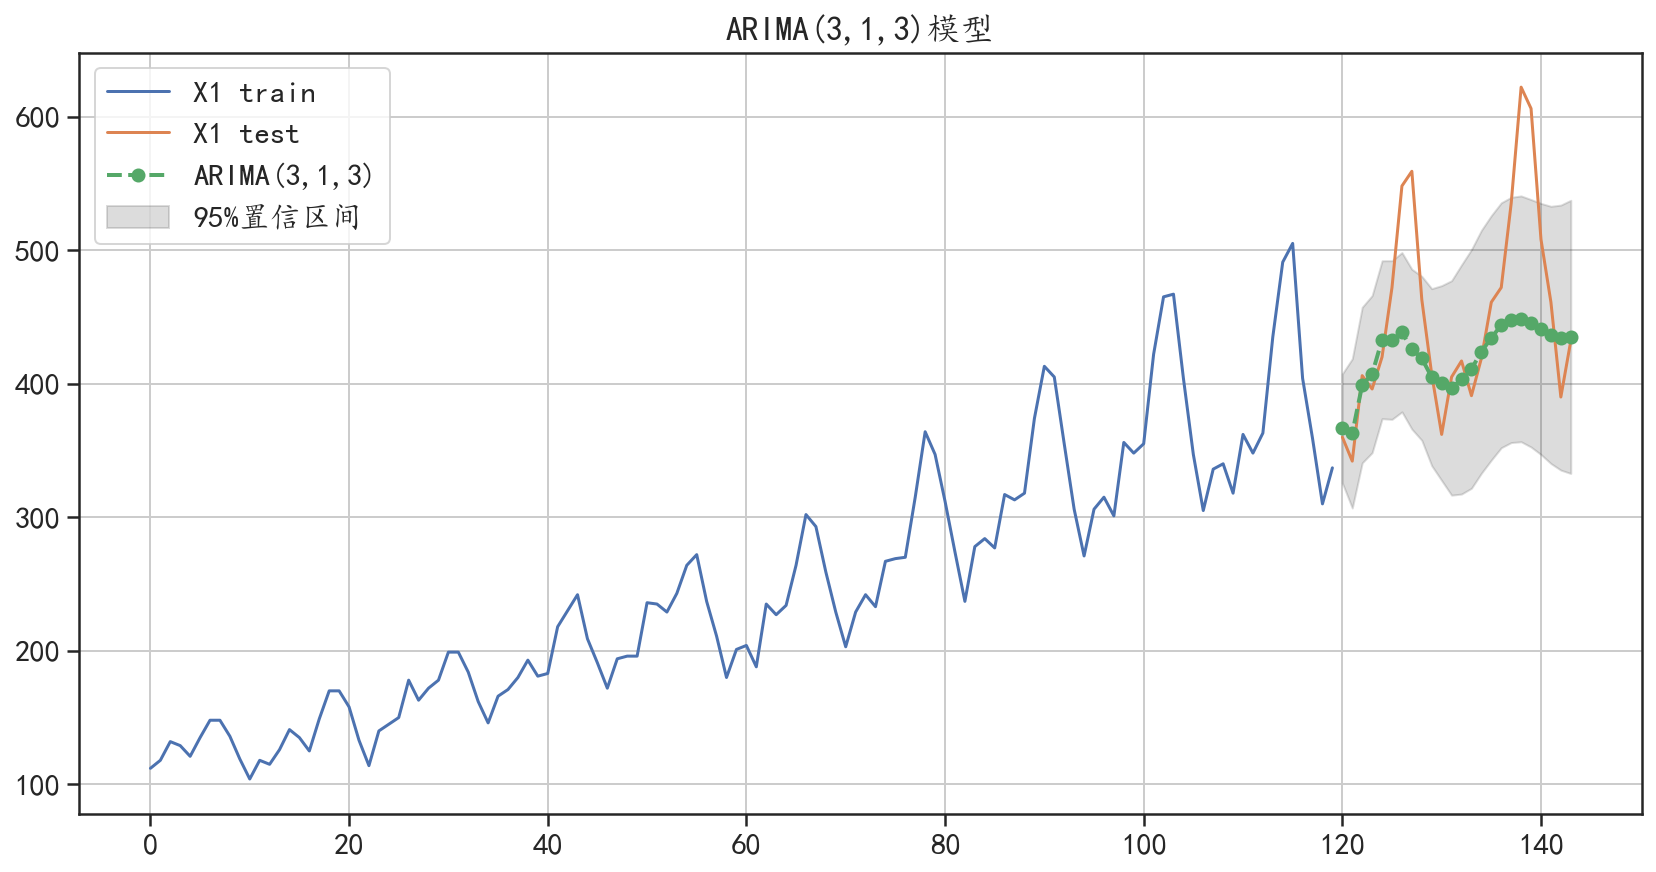

ARMA模型预测的绝对值误差: 45.31232180929982


In [35]:
## 可视化自动搜索参数获得的ARIMA(3,1,3)对测试集进行预测
pre, conf = model.predict(n_periods=24, alpha=0.05,
                          return_conf_int=True)
## 可视化ARIMA(3,1,3)的预测结果，整理数据
y_hat = test.copy(deep = False)
y_hat["arma_pre"] = pre
y_hat["arma_pre_lower"] = conf[:,0]
y_hat["arma_pre_upper"] = conf[:,1]
## 可视化出预测结果
plt.figure(figsize=(14,7))
train["X1"].plot(figsize=(14,7),label = "X1 train")
test["X1"].plot(label = "X1 test")
y_hat["arma_pre"].plot(style="g--o", lw=2,label="ARIMA(3,1,3)")
## 可视化出置信区间
plt.fill_between(y_hat.index, y_hat["arma_pre_lower"], 
                 y_hat["arma_pre_upper"],color='k',alpha=.15,
                 label = "95%置信区间")
plt.legend()
plt.grid()
plt.title("ARIMA(3,1,3)模型")
plt.show()

# 计算预测结果和真实值的误差
print("ARMA模型预测的绝对值误差:",
      mean_absolute_error(test["X1"],y_hat["arma_pre"]))

## 可以发现模型的预测效果比人工确定参数的ARIMA模型效果更好一些

### 6.4 SARIMA模型


In [36]:
## 使用可以拟合周期性的SARIMA模型进行建模

## 针对模型自动寻找合适的参数
model = pm.auto_arima(train["X1"].values,
                      start_p=1, start_q=1, # p,q的开始值
                      max_p=12, max_q=12, # 最大的p和q
                      test="kpss",       # 使用kpss检验确定d
                      d = None,          # 自动选择合适的d
                      m=12,               # 序列的周期
                      seasonal=True,         # 有季节性趋势
                      start_P = 0,start_Q = 0, # P,Q的开始值
                      max_P=5, max_Q=5,      # 最大的P和Q
                      D = None,              # 自动选择合适的D
                      trace=True,error_action='ignore',  
                      suppress_warnings=True, stepwise=True)

print(model.summary())

## 找到的最合适的模型为 SARIMA(3,0,1)x(0,1,0,12)

Performing stepwise search to minimize aic
Fit ARIMA(1,0,1)x(0,1,0,12) [intercept=True]; AIC=809.448, BIC=820.177, Time=0.106 seconds
Fit ARIMA(0,0,0)x(0,1,0,12) [intercept=True]; AIC=910.236, BIC=915.601, Time=0.018 seconds
Fit ARIMA(1,0,0)x(1,1,0,12) [intercept=True]; AIC=810.646, BIC=821.375, Time=0.309 seconds
Fit ARIMA(0,0,1)x(0,1,1,12) [intercept=True]; AIC=860.575, BIC=871.304, Time=0.205 seconds
Fit ARIMA(0,0,0)x(0,1,0,12) [intercept=False]; AIC=1060.479, BIC=1063.161, Time=0.016 seconds
Fit ARIMA(1,0,1)x(1,1,0,12) [intercept=True]; AIC=810.998, BIC=824.409, Time=0.364 seconds
Fit ARIMA(1,0,1)x(0,1,1,12) [intercept=True]; AIC=811.075, BIC=824.485, Time=0.261 seconds
Fit ARIMA(1,0,1)x(1,1,1,12) [intercept=True]; AIC=812.285, BIC=828.378, Time=0.706 seconds
Fit ARIMA(0,0,1)x(0,1,0,12) [intercept=True]; AIC=859.115, BIC=867.161, Time=0.058 seconds
Fit ARIMA(1,0,0)x(0,1,0,12) [intercept=True]; AIC=809.411, BIC=817.458, Time=0.064 seconds
Fit ARIMA(1,0,0)x(0,1,1,12) [intercept=True]

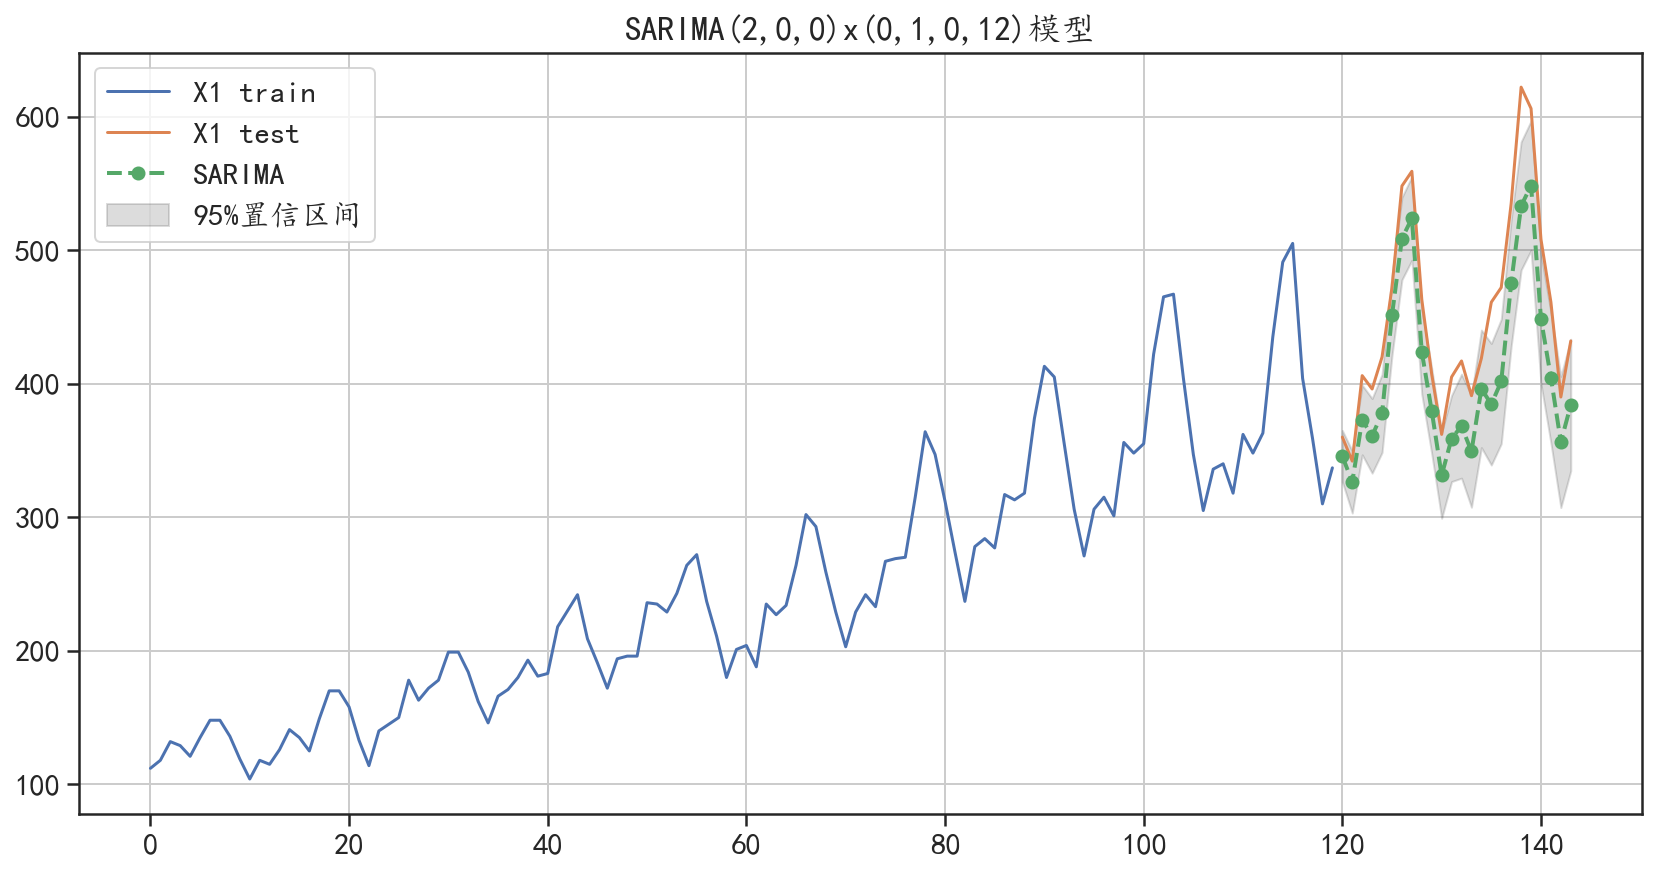

SARIMA模型预测的绝对值误差: 43.464894357672186


In [37]:
## 可视化自动搜索参数获得的SARIMA(2, 0, 0)x(0, 1, 0, 12)对测试集进行预测
pre, conf = model.predict(n_periods=24, alpha=0.05,
                          return_conf_int=True)
## 可视化SARIMAX(2, 0, 0)x(0, 1, 0, 12)的预测结果，整理数据
y_hat = test.copy(deep = False)
y_hat["sarima_pre"] = pre
y_hat["sarima_pre_lower"] = conf[:,0]
y_hat["sarima_pre_upper"] = conf[:,1]
## 可视化出预测结果
plt.figure(figsize=(14,7))
train["X1"].plot(figsize=(14,7),label = "X1 train")
test["X1"].plot(label = "X1 test")
y_hat["sarima_pre"].plot(style="g--o", lw=2,label="SARIMA")
## 可视化出置信区间
plt.fill_between(y_hat.index, y_hat["sarima_pre_lower"], 
                 y_hat["sarima_pre_upper"],color='k',alpha=.15,
                 label = "95%置信区间")
plt.legend()
plt.grid()
plt.title("SARIMA(2,0,0)x(0,1,0,12)模型")
plt.show()

# 计算预测结果和真实值的误差
print("SARIMA模型预测的绝对值误差:",
      mean_absolute_error(test["X1"],y_hat["sarima_pre"]))

## 可以发现SARIMA模型很好的预测了算法的变化趋势，但是预测值比真实值较小，预测效果也很不错

### 6.6 多元时间序列分析ARIMAX

In [5]:
## 读取数据
datadf = pd.read_csv("data/chap6/gas furnace data.txt",sep="\s+")
datadf.columns = ["GasRate","C02"]
## GasRate:输入天然气速率，C02：输出二氧化碳浓度
print(datadf.head())

   GasRate   C02
0   -0.109  53.8
1    0.000  53.6
2    0.178  53.5
3    0.339  53.5
4    0.373  53.4


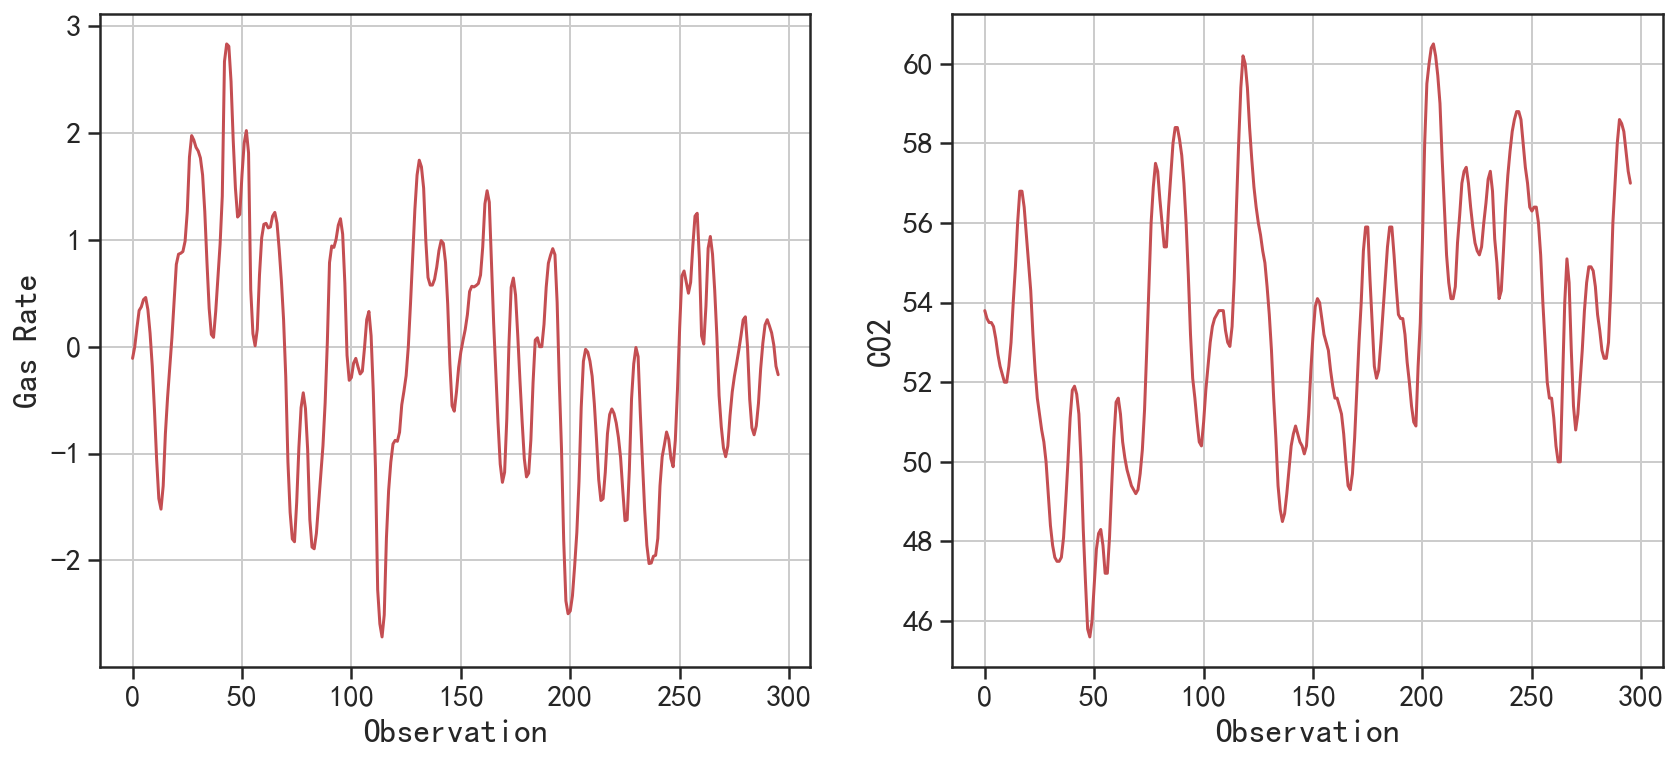

In [6]:
## 可视化出两个序列的变换情况
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
datadf.GasRate.plot(c="r")
plt.grid()
plt.xlabel("Observation")
plt.ylabel("Gas Rate")
plt.subplot(1,2,2)
datadf.C02.plot(c="r")
plt.grid()
plt.xlabel("Observation")
plt.ylabel("C02")
plt.show()

In [7]:
## 前面百分之75做训练集，后面百分之25做测试集
trainnum = np.int(datadf.shape[0]*0.75)
traidata = datadf.iloc[0:trainnum,:]
testdata = datadf.iloc[trainnum:datadf.shape[0],:]
print(traidata.shape)
print(testdata.shape)

(222, 2)
(74, 2)


In [8]:
## 1:单位根检验检验序列的平稳性,ADF 检验
dftest = adfuller(datadf.GasRate,autolag='BIC')
dfoutput = pd.Series(dftest[0:4],
    index=['adf','p-value','usedlag','Number of Observations Used'])
print("GasRate 检验结果:\n",dfoutput)

dftest = adfuller(datadf.C02,autolag='BIC')
dfoutput = pd.Series(dftest[0:4],
    index=['adf','p-value','usedlag','Number of Observations Used'])
print("C02 检验结果:\n",dfoutput)

## p-value均小于0.05，说明在置信度为95％水平下，两个序列均是平稳序列。

GasRate 检验结果:
 adf                             -4.878952
p-value                          0.000038
usedlag                          2.000000
Number of Observations Used    293.000000
dtype: float64
C02 检验结果:
 adf                             -2.947057
p-value                          0.040143
usedlag                          3.000000
Number of Observations Used    292.000000
dtype: float64


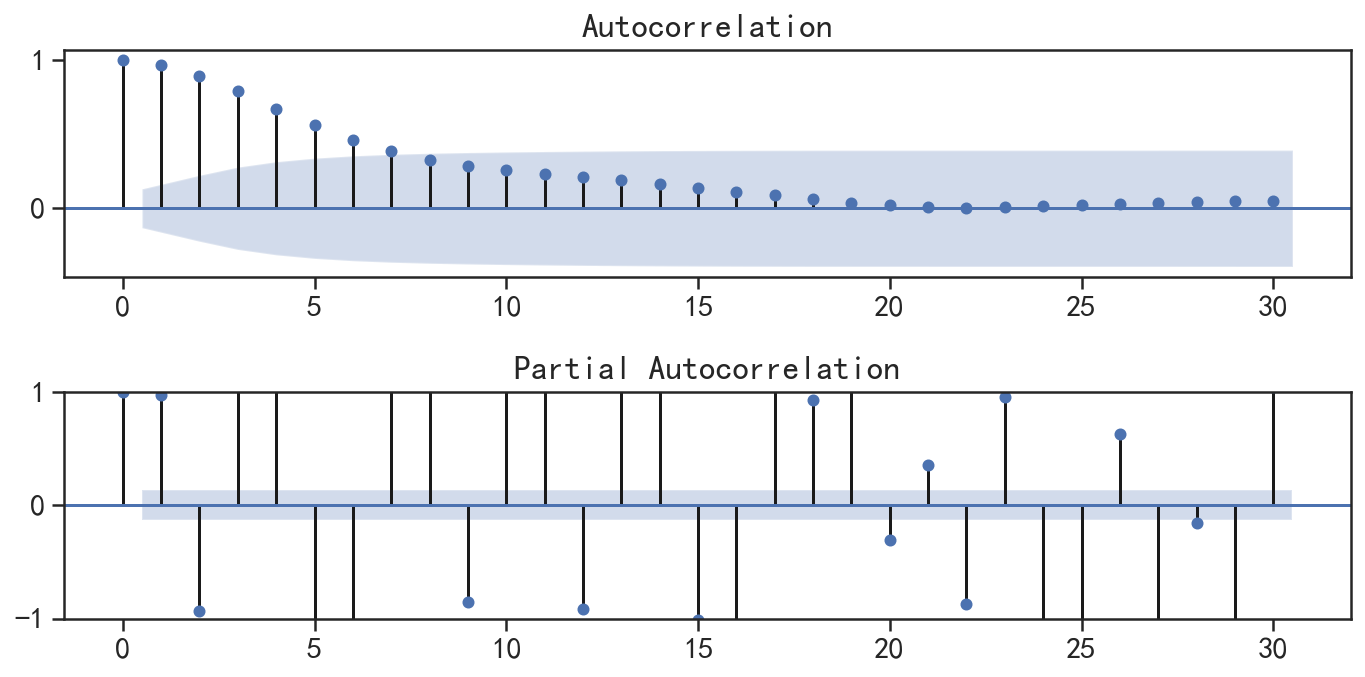

In [42]:
## 可视化序列的自相关和偏相关图
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(traidata.C02, lags=30, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(traidata.C02, lags=30, ax=ax2)
plt.ylim([-1,1])
plt.tight_layout()
plt.show()

In [43]:
## 建立ARIMAX（1，0，2）模型
model  = pf.ARIMAX(data=traidata,formula="C02~GasRate",ar=1,ma=2,integ=0)
model_1 = model.fit("MLE")
model_1.summary()

Normal ARIMAX(1,0,2)                                                                                      
======================================================= ==================================================
Dependent Variable: C02                                 Method: MLE                                       
Start Date: 2                                           Log Likelihood: -71.9362                          
End Date: 221                                           AIC: 155.8725                                     
Number of observations: 220                             BIC: 176.2343                                     
Latent Variable                          Estimate   Std Error  z        P>|z|    95% C.I.                 
======================================== ========== ========== ======== ======== =========================
AR(1)                                    0.9086     0.0191     47.5425  0.0      (0.8712 | 0.9461)        
MA(1)                                

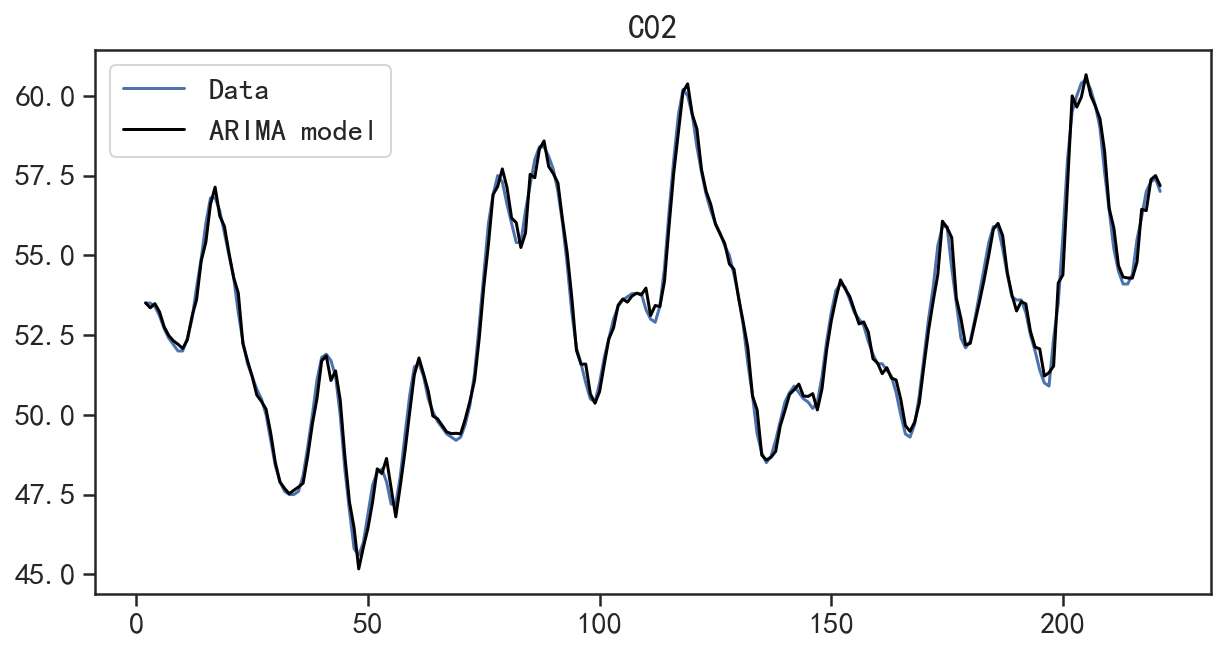

In [44]:
## 可视化模型在训练集上的拟合情况
model.plot_fit(figsize=(10,5))

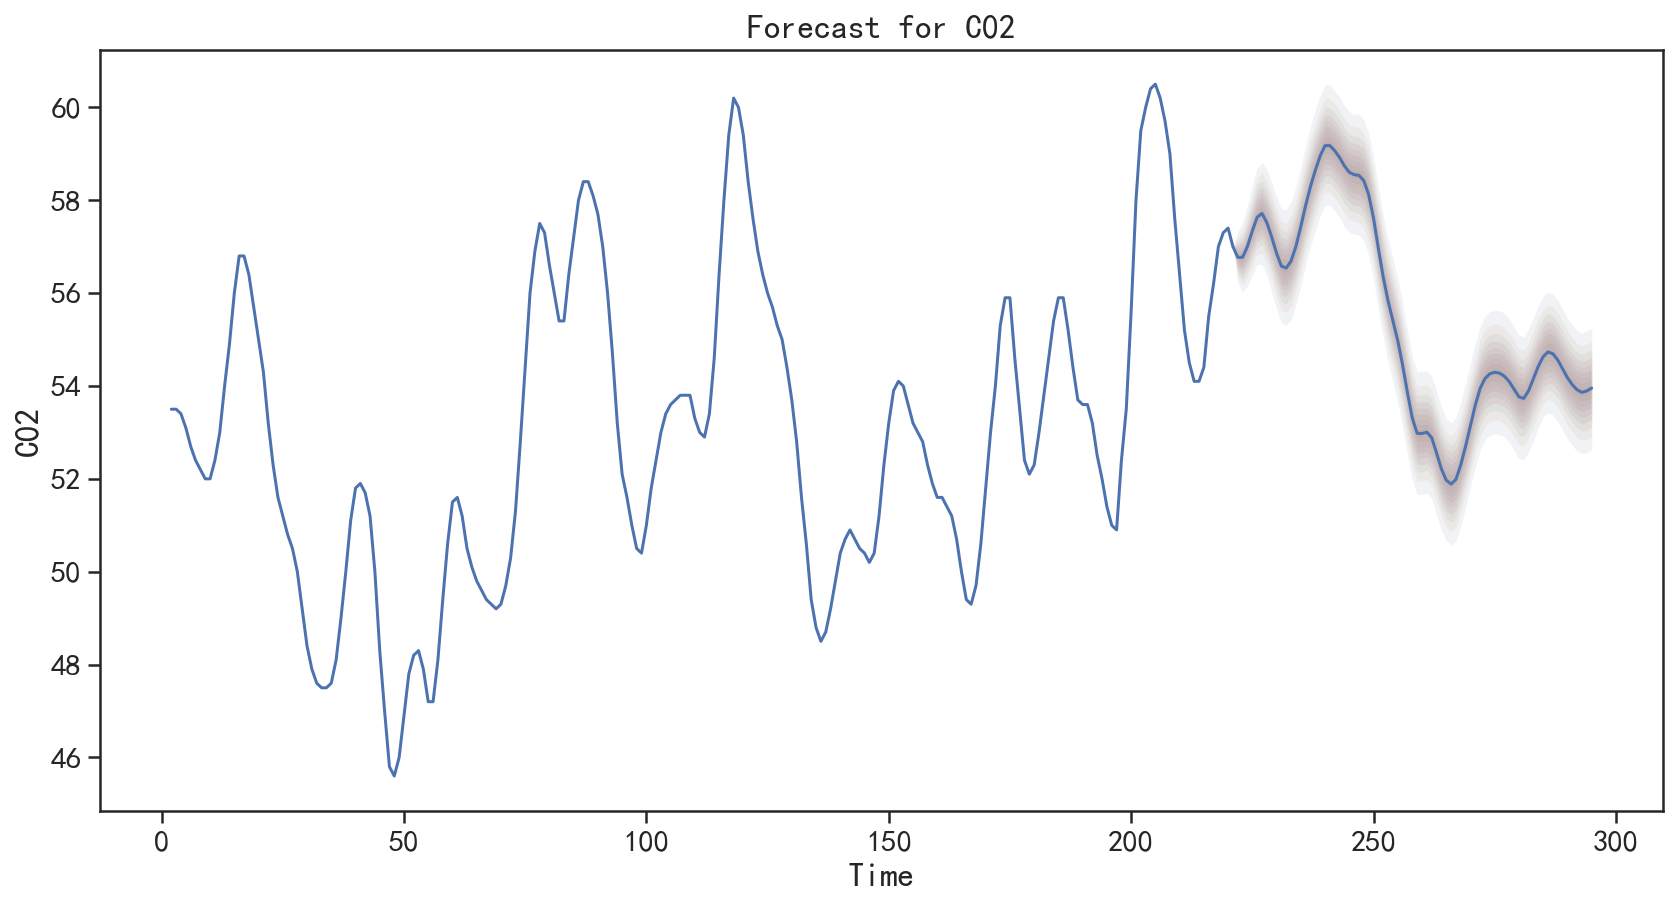

In [45]:
## 可视化模型的在测试集上的预测结果
model.plot_predict(h=testdata.shape[0], ## 往后预测的数目
                   oos_data=testdata,  ## 测试数据集
                   past_values=traidata.shape[0], ## 图像显示训练集的多少数据 
                   figsize=(14,7))
plt.show()

In [46]:
## 预测新的数据
C02pre = model.predict(h=testdata.shape[0], ## 往后预测多少步
                       oos_data=testdata,  ## 测试数据集
                       intervals=True, ## 同时预测置信区间
                      )
print("在测试集上绝对值预测误差为:",mean_absolute_error(testdata.C02,C02pre.C02))
print(C02pre.head())

在测试集上绝对值预测误差为: 1.5731456243696424
           C02  1% Prediction Interval  5% Prediction Interval  \
222  56.770585               55.988034               56.225457   
223  56.772237               55.720472               56.039130   
224  57.009510               55.771620               56.138492   
225  57.339511               55.978476               56.376392   
226  57.635704               56.191302               56.611199   

     95% Prediction Interval  99% Prediction Interval  
222                57.331513                57.563458  
223                57.504168                57.818328  
224                57.877225                58.232795  
225                58.300240                58.702436  
226                58.661854                59.081403  


In [47]:
C02pre.head()

,C02,1% Prediction Interval,5% Prediction Interval,95% Prediction Interval,99% Prediction Interval
222,56.770585,55.988034,56.225457,57.331513,57.563458
223,56.772237,55.720472,56.039130,57.504168,57.818328
224,57.009510,55.771620,56.138492,57.877225,58.232795
225,57.339511,55.978476,56.376392,58.300240,58.702436
226,57.635704,56.191302,56.611199,58.661854,59.081403


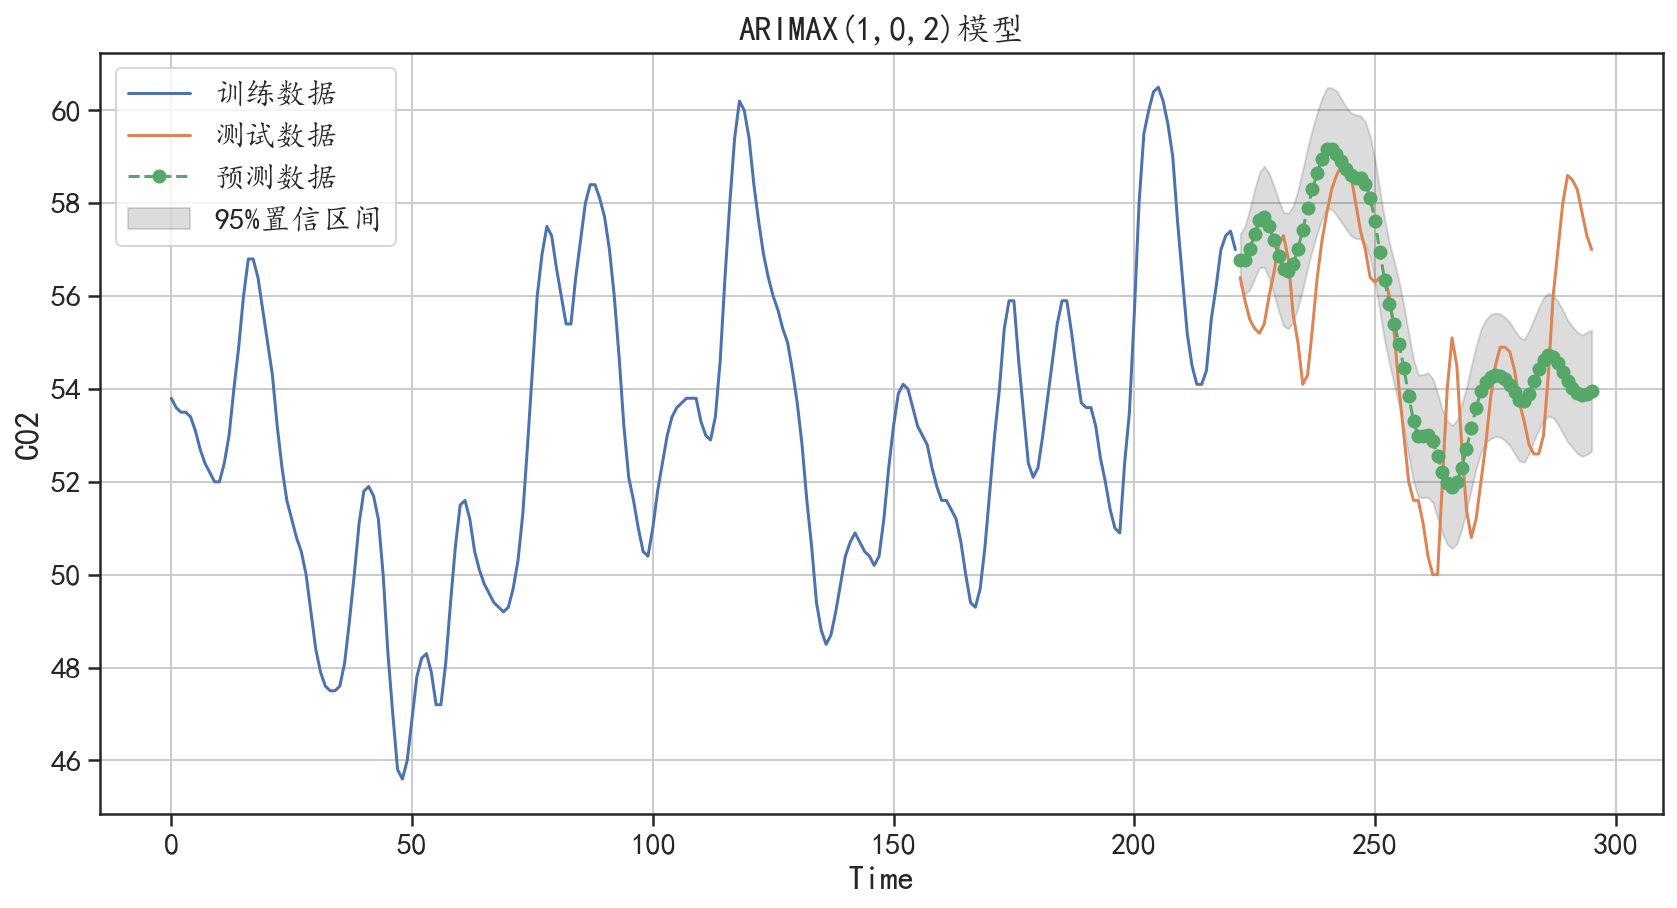

In [48]:
## 可视化原始数据和预测数据进行对比
traidata.C02.plot(figsize=(14,7),label="训练数据")
testdata.C02.plot(figsize=(14,7),label="测试数据")
C02pre.C02.plot(style = "g--o",label="预测数据")
## 可视化出置信区间
plt.fill_between(C02pre.index, C02pre["5% Prediction Interval"], 
                 C02pre["95% Prediction Interval"],color='k',alpha=.15,
                 label = "95%置信区间")
plt.grid()
plt.xlabel("Time")
plt.ylabel("C02")
plt.title("ARIMAX(1,0,2)模型")
plt.legend(loc=2)
plt.show()

In [49]:
## 参数搜索寻找合适的p,q
p = np.arange(6)
q = np.arange(6)
pp,qq = np.meshgrid(p,q)
resultdf = pd.DataFrame(data = {"arp":pp.flatten(),"mrq":qq.flatten()})
resultdf["bic"] = np.double(pp.flatten())
resultdf["mae"] = np.double(qq.flatten())
## 迭代循环建立多个模型
for ii in resultdf.index:
    model_i = pf.ARIMAX(data=traidata,formula="C02~GasRate",ar=resultdf.arp[ii],ma=resultdf.mrq[ii],integ=0)
    try: 
        modeli_fit = model_i.fit("MLE")
        bic = modeli_fit.bic
        C02_pre = model.predict(h=testdata.shape[0],oos_data=testdata)
        mae = mean_absolute_error(testdata.C02,C02_pre.C02)
    except:
        bic = np.nan
    resultdf.bic[ii] = bic
    resultdf.mae[ii] = mae
print("模型迭代结束")


模型迭代结束


In [50]:
## 按照BIC寻找合适的模型
print(resultdf.sort_values(by="bic").head())

    arp  mrq        bic       mae
15    3    2   0.820429  1.573146
17    5    2  21.192451  1.573146
11    5    1  29.406913  1.573146
28    4    4  31.267202  1.573146
27    3    4  44.280754  1.573146


In [9]:
## 重新建立效果较好的模型
model  = pf.ARIMAX(data=traidata,formula="C02~GasRate",ar=3,ma=2,integ=0)
model_1 = model.fit("MLE")
model_1.summary()

Normal ARIMAX(3,0,2)                                                                                      
======================================================= ==================================================
Dependent Variable: C02                                 Method: MLE                                       
Start Date: 3                                           Log Likelihood: 20.4678                           
End Date: 221                                           AIC: -24.9356                                     
Number of observations: 219                             BIC: 2.177                                        
Latent Variable                          Estimate   Std Error  z        P>|z|    95% C.I.                 
======================================== ========== ========== ======== ======== =========================
AR(1)                                    2.3482     0.0372     63.075   0.0      (2.2753 | 2.4212)        
AR(2)                                

在测试集上绝对值预测误差为: 1.1115309949695789


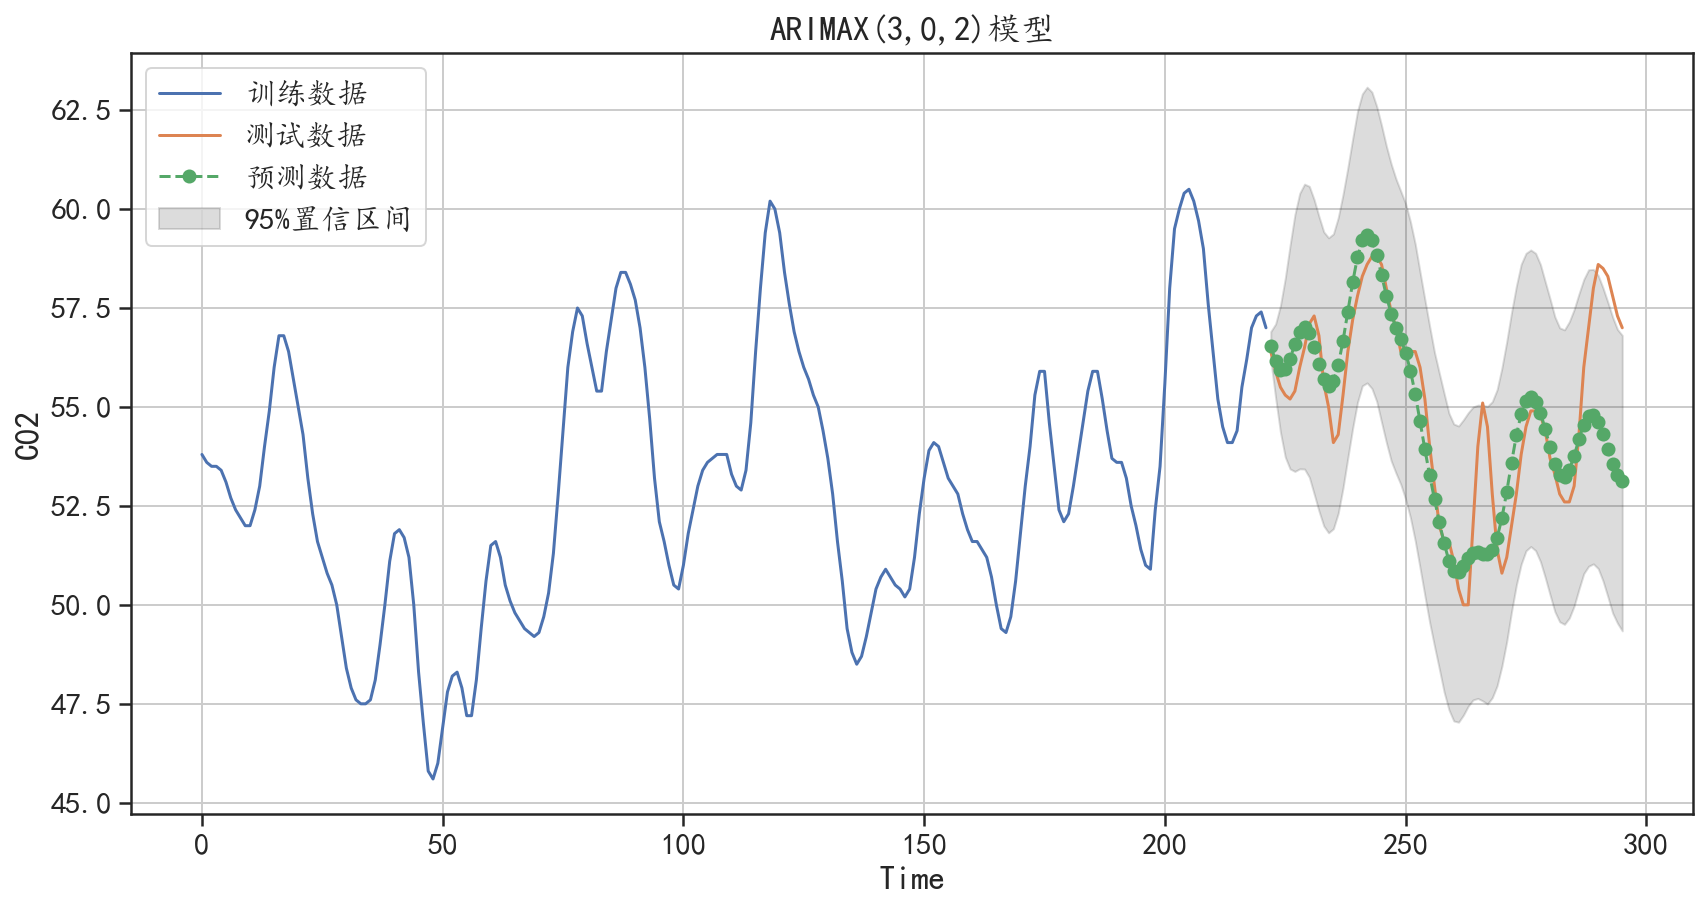

In [10]:
## 预测新的数据
C02pre = model.predict(h=testdata.shape[0], ## 往后预测多少步
                       oos_data=testdata,  ## 测试数据集
                       intervals=True)
print("在测试集上绝对值预测误差为:",mean_absolute_error(testdata.C02,C02pre.C02))
## 可视化原始数据和预测数据进行对比
traidata.C02.plot(figsize=(14,7),label="训练数据")
testdata.C02.plot(figsize=(14,7),label="测试数据")
C02pre.C02.plot(style = "g--o",label="预测数据")
## 可视化出置信区间
plt.fill_between(C02pre.index, C02pre["5% Prediction Interval"], 
                 C02pre["95% Prediction Interval"],color='k',alpha=.15,
                 label = "95%置信区间")
plt.grid()
plt.xlabel("Time")
plt.ylabel("C02")
plt.title("ARIMAX(3,0,2)模型")
plt.legend(loc=2)
plt.show()

### 6.5 prophet时间序列预测


In [5]:
## prophet对时间序列进行预测时，需要的数据为数据表格式，并且包含时间变量ds和数值变量y

## 使用prophet模型进行时间序列的预测

## 读取数据
df = pd.read_csv("data/chap6/AirPassengers.csv")
df.columns = ["ds","y"]
## 定义时间数据的数据类型
df["ds"] = pd.to_datetime(df["ds"])
print(df.head())

          ds    y
0 1949-01-01  112
1 1949-02-01  118
2 1949-03-01  132
3 1949-04-01  129
4 1949-05-01  121


In [6]:
## 数据切分为训练集和测试集
train = df[0:120]
test = df[120:]

## 构建模型
model = Prophet(growth = "linear",   # 线性增长趋势
                yearly_seasonality = True, # 年周期的趋势
                weekly_seasonality = False,# 以周为周期的趋势
                daily_seasonality = False,  # 以天为周期的趋势
                seasonality_mode = "multiplicative", # 季节周期性模式
                seasonality_prior_scale = 12, # 季节周期性长度
               )
model.fit(train)
## 使用模型对测试集进行预测
forecast = model.predict(test)
## 输出部分预测结果
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())
print("在测试集上绝对值预测误差为:",mean_absolute_error(test.y,forecast.yhat))

INFO:numexpr.utils:NumExpr defaulting to 8 threads.


          ds        yhat  yhat_lower  yhat_upper
0 1959-01-01  368.542752  356.998558  379.747326
1 1959-02-01  358.317627  346.544210  370.858007
2 1959-03-01  406.314560  394.439755  418.404881
3 1959-04-01  395.163652  383.408878  406.728424
4 1959-05-01  404.083929  392.257283  416.820298
在测试集上绝对值预测误差为: 25.382391862162734


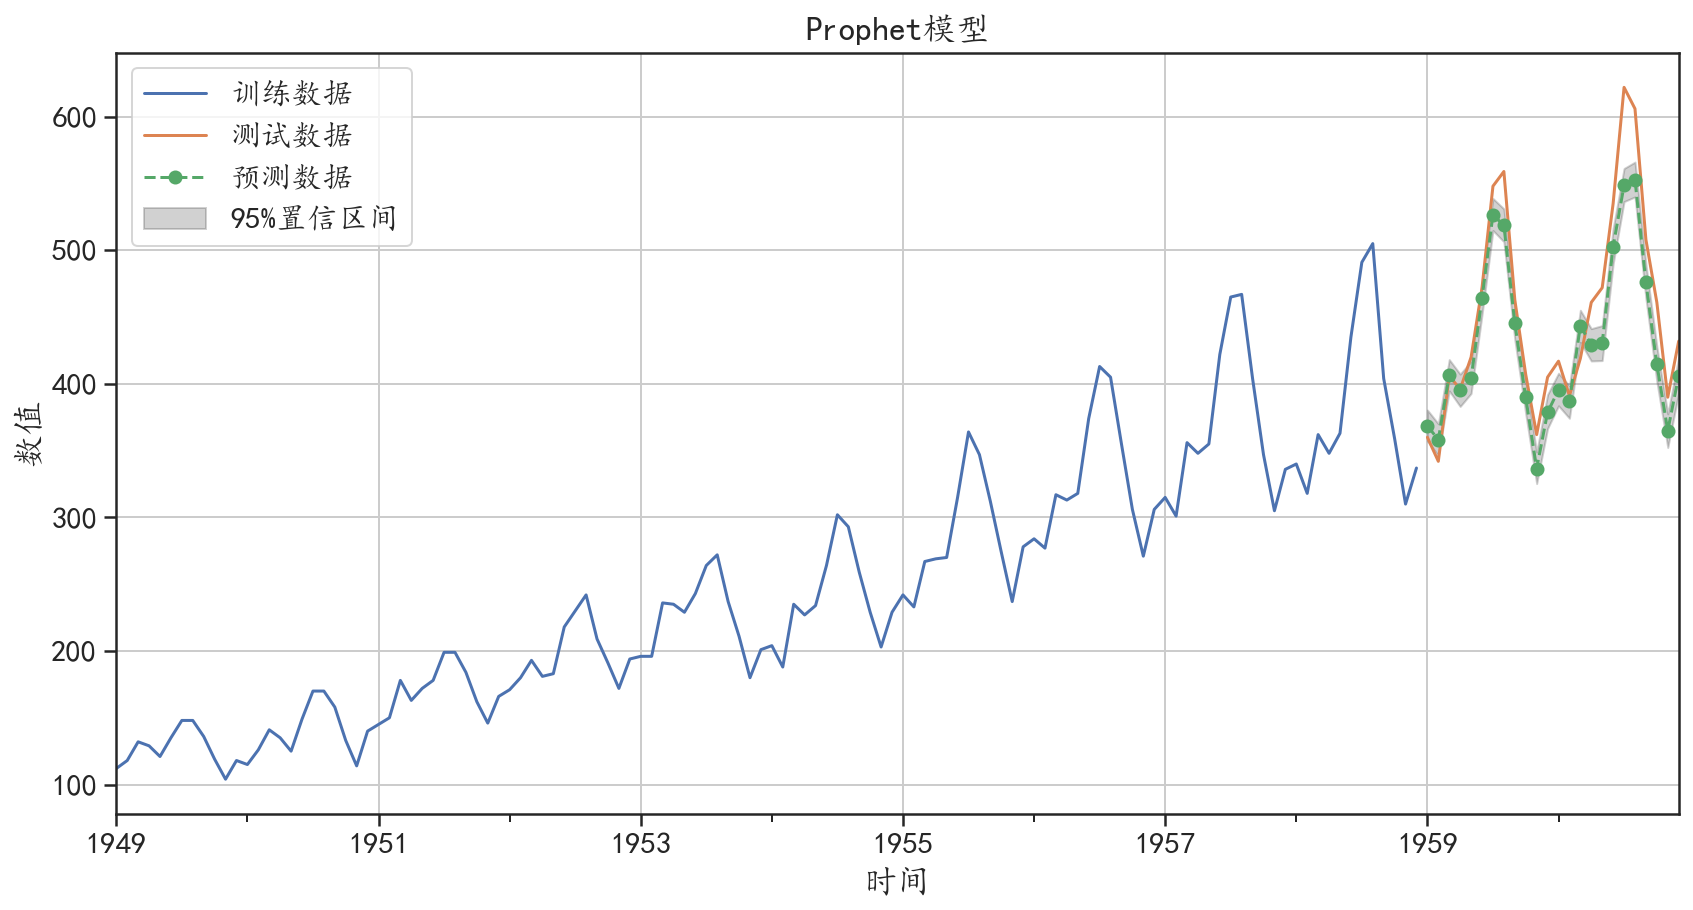

In [55]:
## 可视化原始数据和预测数据进行对比
fig, ax = plt.subplots()
train.plot(x = "ds",y = "y",figsize=(14,7),label="训练数据",ax = ax)
test.plot(x = "ds",y = "y",figsize=(14,7),label="测试数据",ax = ax)
forecast.plot(x = "ds",y = "yhat",style = "g--o",label="预测数据",ax = ax)
## 可视化出置信区间
ax.fill_between(test["ds"].values, forecast["yhat_lower"], 
                forecast["yhat_upper"],color='k',alpha=.2,
                label = "95%置信区间")
plt.grid()
plt.xlabel("时间")
plt.ylabel("数值")
plt.title("Prophet模型")
plt.legend(loc=2)
plt.show()

## 从可视化结果中可发现模型的预测效果很好

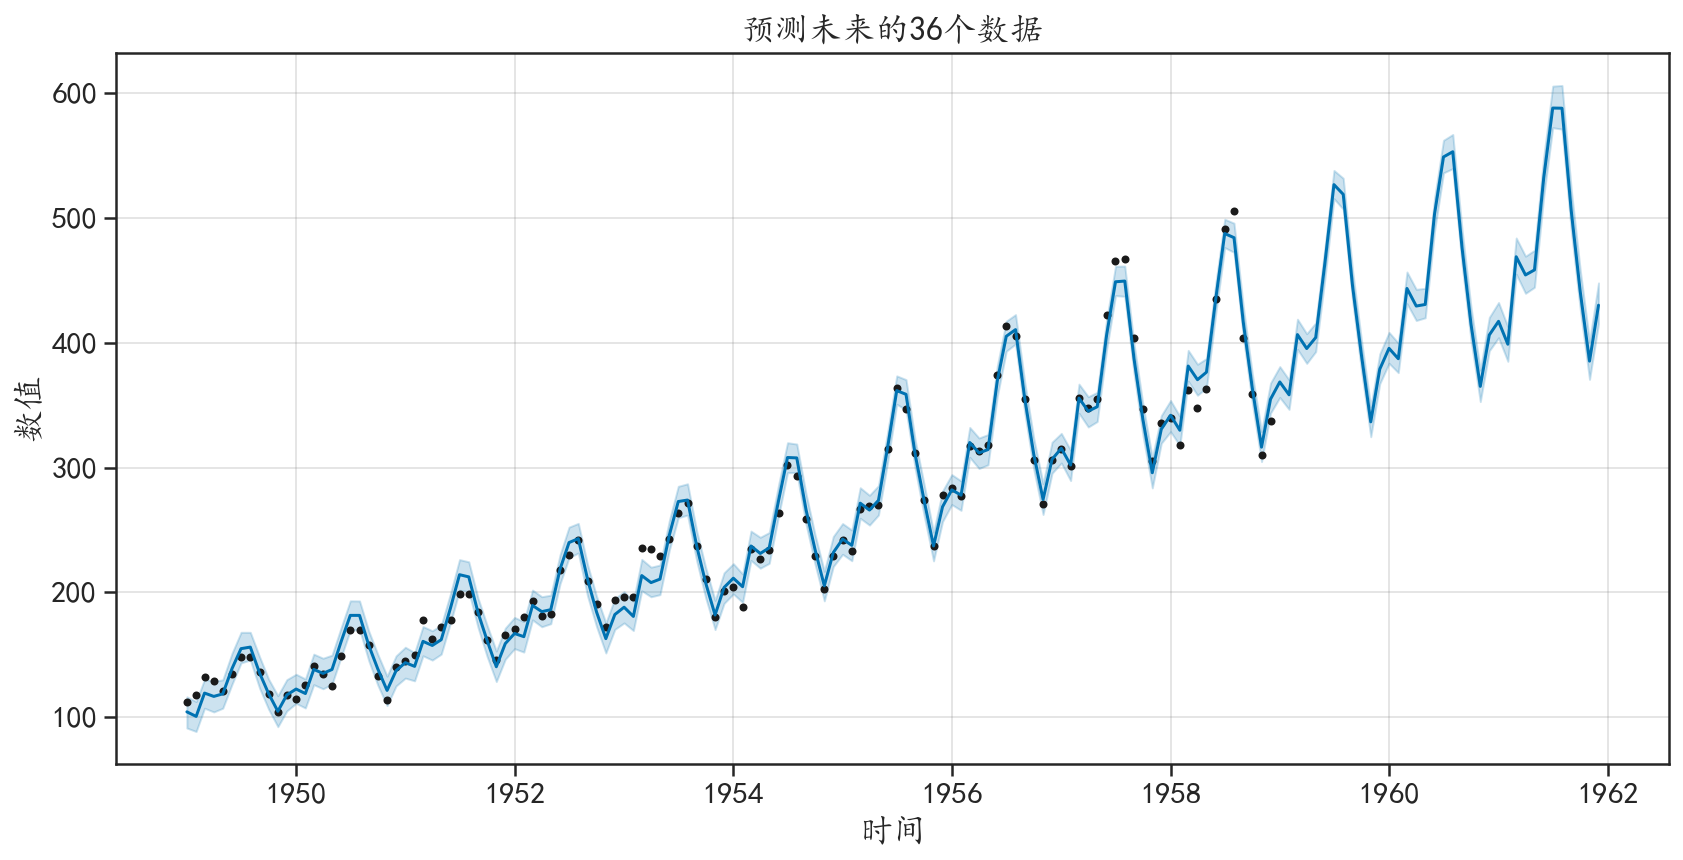

In [56]:
## 也可以通过model.make_future_dataframe获取对训练数据和未来数据进行预测的时间
future = model.make_future_dataframe(periods=36,freq = "MS")
forecast = model.predict(future)
## 可视化预测结果
model.plot(forecast,figsize=(12,6),xlabel = "时间",
           ylabel = "数值")
plt.title("预测未来的36个数据")
plt.show()

## 在图像中散点是训练数据中的真实数据，曲线是模型的拟合数据和预测数据，
## 阴影则表示预测值的置信区间

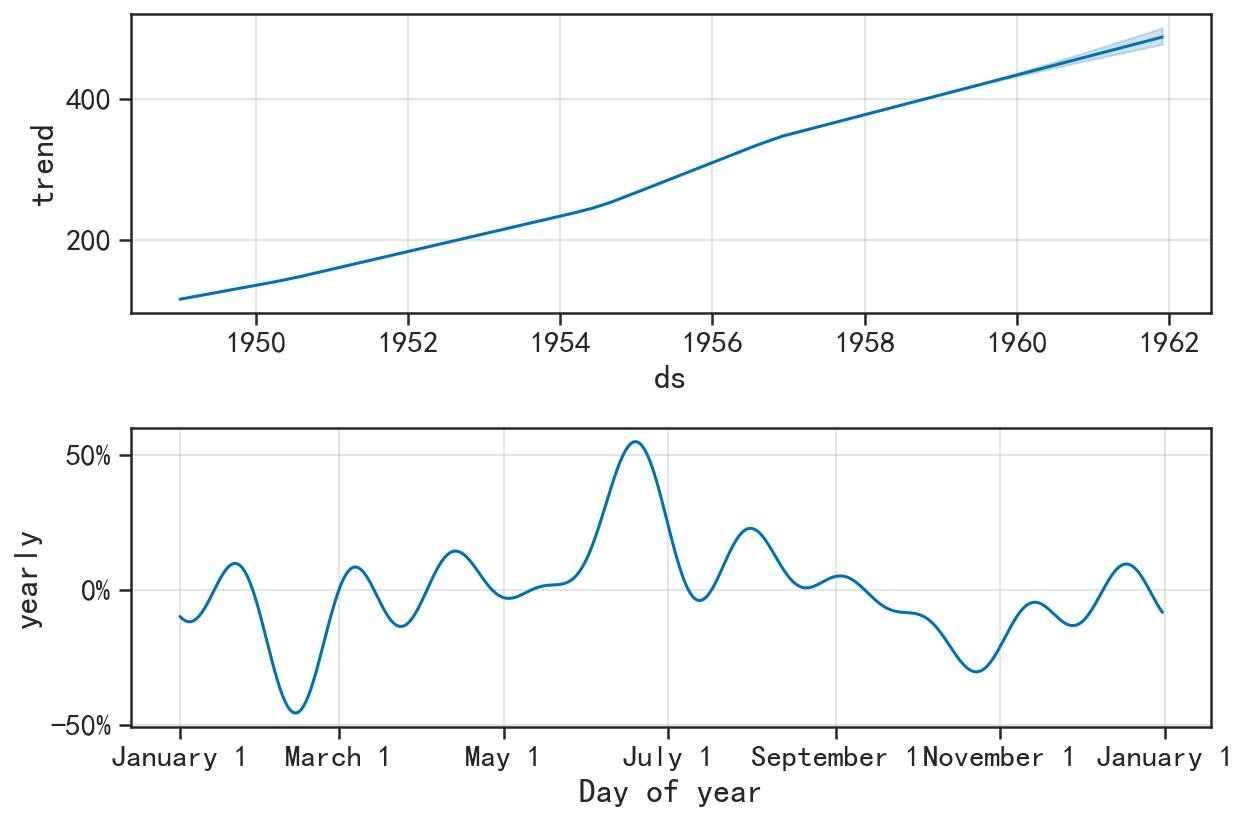

In [57]:
## 使用model.plot_components可视化出模型中的主要成分
model.plot_components(forecast)
plt.show()

## 第一幅图表示模型中的线性变化趋势
## 第二幅图表示在一年的时间内数量的增长或见效快的变化情况

#### 针对同一个数据，不同模型在测试集上的预测误差
|模型|绝对值误差|
|:----:|:----:|
|简单移动平均|82.5520|
|简单指数平滑|81.1011|
|霍尔特(Holt)线性趋势法|54.7274|
|Holt-Winters季节性预测模型|30.0682|
|AR(2)|165.7960|
|ARMA(2,1)|147.265|
|ARMA(3,2)|158.1146|
|ARIMA(2,1,1)|55.3876|
|ARIMA(3,1,3)|45.3123|
|SARIMA(2,0,0)x(0,1,0,12)|43.4648|
|Prophet|25.3555|


### 6.7 时序数据的异常值检测


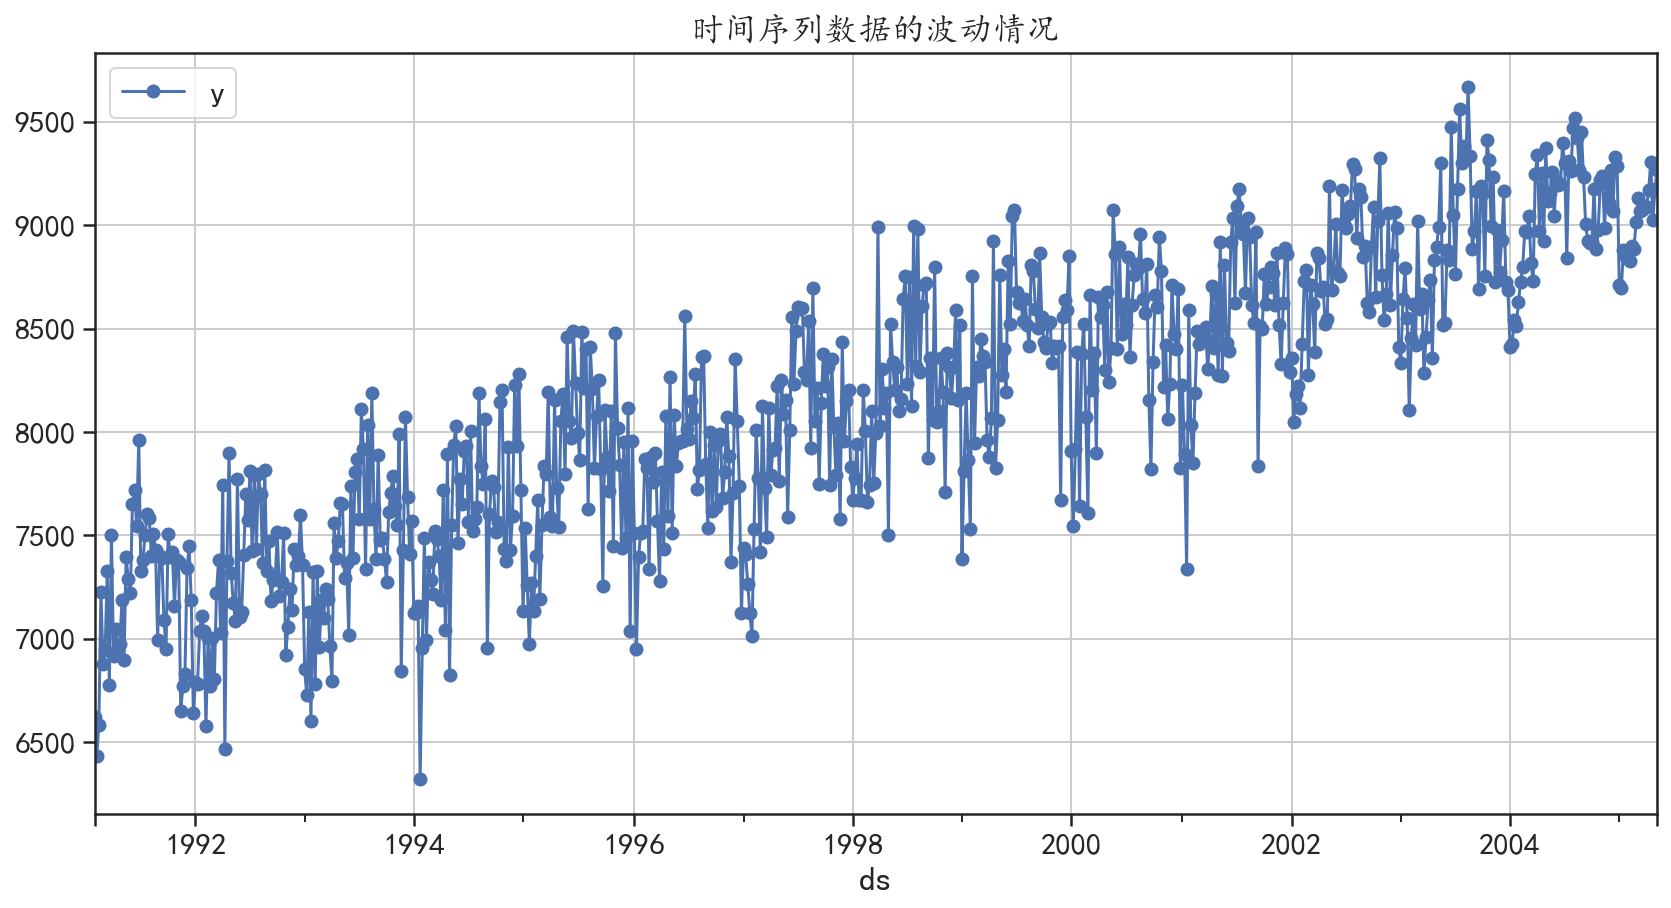

In [58]:
## 使用prophet检测时间序列是否有异常值

## 从1991年2月到2005年5月，每周提供美国成品汽车汽油产品的时间序列（每天数千桶）

## 数据准备
data = pm.datasets.load_gasoline()
datadf = pd.DataFrame({"y":data})
datadf["ds"] = pd.date_range(start="1991-2",periods=len(data),freq="W")
## 可视化时间序列的变化情况
datadf.plot(x = "ds",y = "y",style = "b-o",figsize=(14,7))
plt.grid()
plt.title("时间序列数据的波动情况")
plt.show()

In [59]:
## 对该数据建立一个时间序列模型
np.random.seed(1234)  ## 设置随机数种子
model = Prophet(growth="linear",daily_seasonality = False,
                weekly_seasonality=False,
                seasonality_mode = 'multiplicative', 
                interval_width = 0.95,   ## 获取95%的置信区间
                )
model = model.fit(datadf)     # 使用数据拟合模型
forecast = model.predict(datadf)  # 使用模型对数据进行预测
forecast["y"] = datadf["y"].reset_index(drop = True)
forecast[["ds","y","yhat","yhat_lower","yhat_upper"]].head()

,ds,y,yhat,yhat_lower,yhat_upper
0,1991-02-03,6621.0,6767.051491,6294.125979,7303.352309
1,1991-02-10,6433.0,6794.736479,6299.430616,7305.414252
2,1991-02-17,6582.0,6855.096282,6352.579489,7379.717614
3,1991-02-24,7224.0,6936.976642,6415.157617,7445.523000
4,1991-03-03,6875.0,6990.511503,6489.781400,7488.240435


In [60]:
## 根据模型预测值的置信区间"yhat_lower"和"yhat_upper"判断样本是否为异常值
def outlier_detection(forecast):
    index = np.where((forecast["y"] <= forecast["yhat_lower"])|
                     (forecast["y"] >= forecast["yhat_upper"]),True,False)
    return index
outlier_index = outlier_detection(forecast)
outlier_df = datadf[outlier_index]
print("异常值的数量为:",np.sum(outlier_index))

异常值的数量为: 38


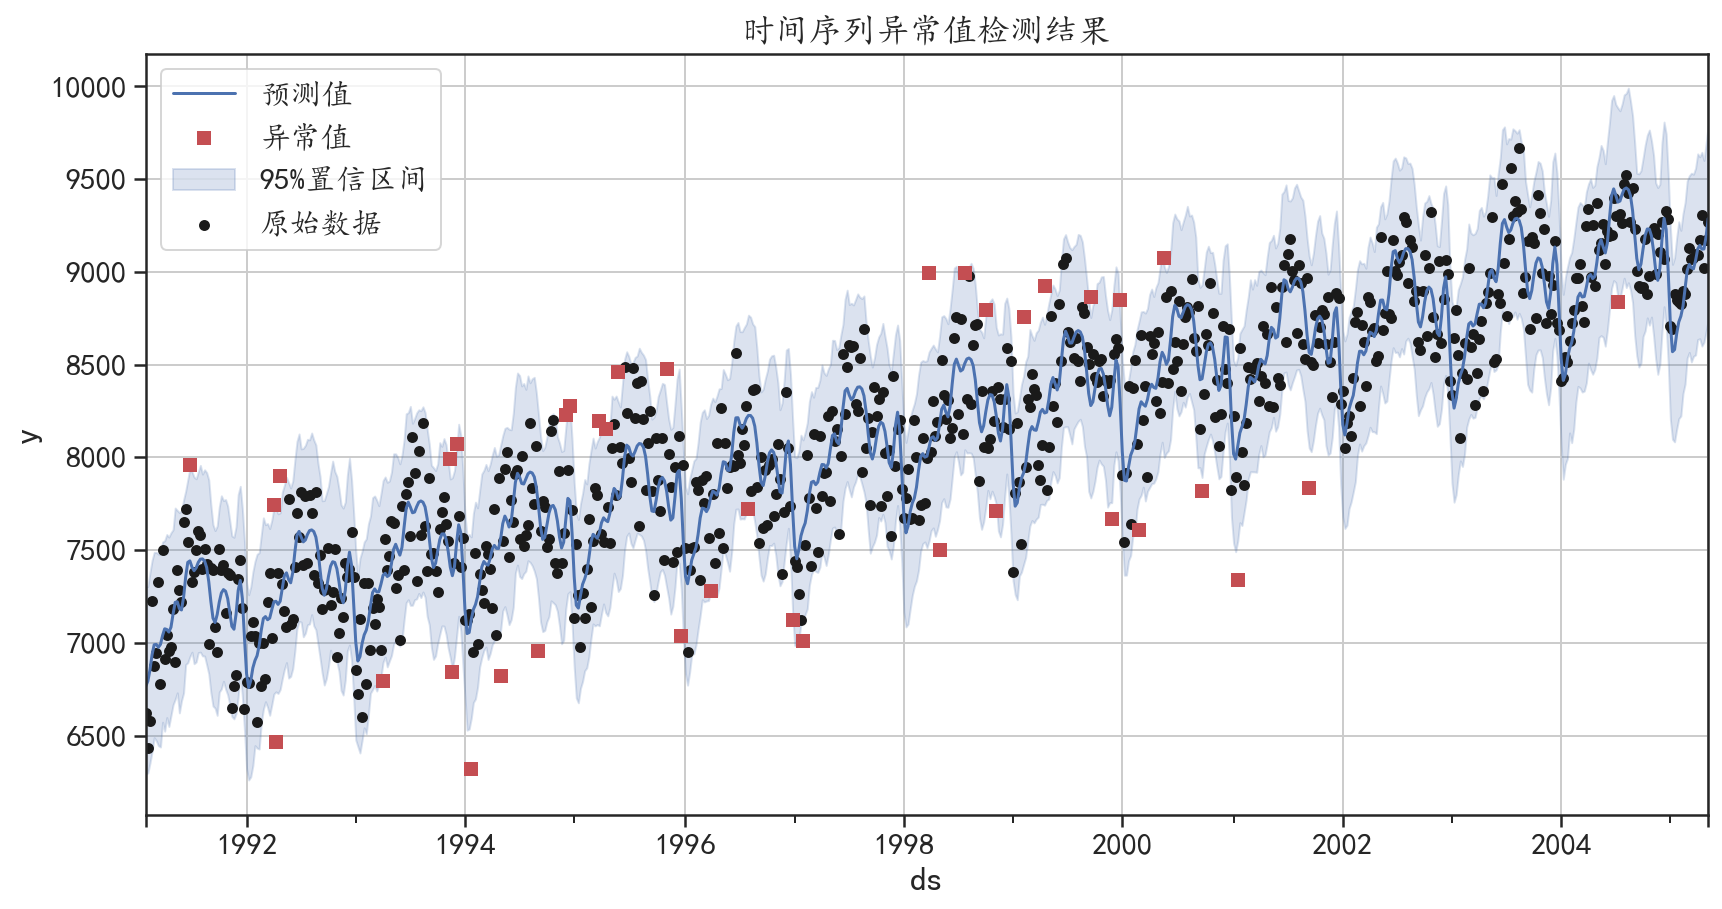

In [61]:
## 可视化异常值的结果
fig, ax = plt.subplots()
## 可视化预测值
forecast.plot(x = "ds",y = "yhat",style = "b-",figsize=(14,7),
              label = "预测值",ax=ax)
## 可视化出置信区间
ax.fill_between(forecast["ds"].values, forecast["yhat_lower"], 
                forecast["yhat_upper"],color='b',alpha=.2,
                label = "95%置信区间")
forecast.plot(kind = "scatter",x = "ds",y = "y",c = "k",
              s = 20,label = "原始数据",ax = ax)
## 可视化出异常值的点
outlier_df.plot(x = "ds",y = "y",style = "rs",ax = ax,
                label = "异常值")
plt.legend(loc = 2)
plt.grid()
plt.title("时间序列异常值检测结果")
plt.show()